## Config
all parameters exposed for clarity

In [1]:
from pathlib import Path
import sys
import json
import shutil
from dataclasses import asdict, replace
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
repo_root = repo_root.parent if repo_root.name == "market_synth_2" else repo_root
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "parml2"))

from market_synth_2.market_synth import (
    ModernMarketSynthConfig,
    NON_MODEL_COLUMNS,
    _apply_offer_downside_extra_cost,
    _apply_offer_downside_to_weekly_demand_path,
    _generate_weekly_demand_path,
    _inventory_cost_basis,
    _sample_offer_downside_regime,
    _simulate_profit_for_weekly_demand_path,
    build_market_synth_bundle,
)
from parml.regressor import PARMLRegressor

In [2]:
random_state = 42
scenario_name = "current_sample"
scenario_description = "Current sample config."
scenario_config_overrides = {}
save_root_name = f"market_synth_scenarios_{datetime.now().strftime('%-Y-%m-%d_%H-%M-%S')}"
run_parml_fit = False
save_setup_names = None

In [2]:
200 * 30 * 12 * 5 * (20-1) / 1_000_000

6.84

In [3]:
# expected offers = cluster_count * base_orders_per_tick * lcogs_seeds
# rows = offers * (qty_ordered_range-1)

# cluster_count - number of SKU behavior types / latent demand archetypes
# base_orders_per_tick - number of offers generated per cluster per date on average
# Current knob set is tuned around ~2% historical acceptance.
# Keep max_ticks=100 when exporting rescaled datasets if you want the same
# latent date dynamics as this notebook inspection.

config = ModernMarketSynthConfig(
    max_ticks=100,
    future_eval_fraction=0.20,
    cluster_count=30,
    cluster_sv_range=(0.01, 3.0),
    cluster_sigma_range=(0.1, 3.0),
    lcogs_seeds=5,
    qty_ordered_range=40,
    weekly_demand_n_weeks=8,
    market_observed_period=27.0,
    market_observed_phase=0.10,
    market_latent_period=19.0,
    market_latent_phase=0.90,
    market_latent_amplitude=0.16,
    market_latent_noise_amplitude=0.10,
    market_profit_trend_strength=1.75,
    volume_period=25.0,
    volume_phase=4.40,
    volume_amplitude=0.65,
    base_orders_per_tick=1000 / (30 * 5),
    lcogs_floor_base=18.0,
    lcogs_floor_amplitude=8.50,
    lcogs_draw_min=2.0,
    lcogs_draw_max=38.0,
    # >1.0 biases LCOGS draws toward the expensive end so good-margin deals
    # stay possible but appear less often on average.
    lcogs_draw_skew=1,
    base_price=34.0,
    holding_cost_per_unit=0.5,
    leftover_writeoff_fraction=1,
    latent_offer_edge_noise_scale=0.18,
    latent_offer_fragility_noise_scale=0.10,
    downside_regime_base_prob=0.01,
    downside_regime_max_prob=0.28,
    downside_regime_best_demand_mult=0.90,
    downside_regime_worst_demand_mult=0.10,
    downside_regime_base_extra_cost_frac=0.00,
    downside_regime_max_extra_cost_frac=0.55,
    rel_sigma_min_cap=0.05,
    rel_sigma_low_cap=1.00,
    rel_sigma_mid_cap=0.55,
    rel_sigma_high_cap=0.25,
    weekly_demand_low_rho=0.35,
    weekly_demand_mid_rho=0.60,
    weekly_demand_high_rho=0.82,
    weekly_demand_low_latent_rel_sigma=0.30,
    weekly_demand_mid_latent_rel_sigma=0.18,
    weekly_demand_high_latent_rel_sigma=0.08,
    policy_period=31.0,
    policy_phase=3.00,
    policy_latent_period=23.0,
    policy_latent_phase=1.30,
    policy_latent_amplitude=0.65,
    policy_latent_noise_amplitude=0.10,
    policy_sv_latent_period=29.0,
    policy_sv_latent_phase=2.10,
    policy_sv_latent_amplitude=0.45,
    policy_sv_latent_noise_amplitude=0.10,
    policy_threshold_base=1.90,
    policy_threshold_amplitude=0.30,
    policy_threshold_noise_amplitude=0.08,
    policy_margin_interaction=0.0,
    policy_sv_interaction=0.0,
    policy_score_noise_scale=0.75,
    policy_exploration_accept_rate=0.01,
    target_acceptance_rate_min=0.02,
    target_acceptance_rate_max=0.10,
    target_acceptance_rate_scale=1.35,
    target_acceptance_rate_market_coupling=0.90,
    market_policy_coupling=0.00,
    low_sv_threshold=0.5,
    mid_sv_threshold=3.0,
    business_qty_mode="sv_coverage",
    business_qty_coverage_low_sv=2.00,
    business_qty_coverage_mid_sv=1.60,
    business_qty_coverage_high_sv=1.25,
    business_operational_cost_per_unit=2.5,
    accepted_safe_unsafe_labels_from_business_qty=False,
    disable_cluster_drop_for_testing=True,
)

# Candidate presets for probing whether current parml2 can show the intended
# bag-angle behavior under cleaner or more aligned synthetic worlds.
candidate_configs = {
    "current_sample": config,
    "clean_aligned": replace(
        config,
        market_observed_period=19.0,
        market_observed_phase=0.90,
        market_latent_period=19.0,
        market_latent_phase=0.90,
        market_latent_noise_amplitude=0.04,
        policy_threshold_amplitude=0.0,
        policy_threshold_noise_amplitude=0.0,
        policy_score_noise_scale=0.10,
        policy_exploration_accept_rate=0.0,
        downside_regime_base_prob=0.0,
        downside_regime_max_prob=0.0,
        downside_regime_base_extra_cost_frac=0.0,
        downside_regime_max_extra_cost_frac=0.0,
    ),
    "clean_aligned_visible_margin": replace(
        config,
        market_observed_period=19.0,
        market_observed_phase=0.90,
        market_latent_period=19.0,
        market_latent_phase=0.90,
        market_latent_noise_amplitude=0.04,
        lcogs_floor_amplitude=12.0,
        lcogs_draw_skew=2.0,
        base_price=32.0,
        policy_threshold_amplitude=0.0,
        policy_threshold_noise_amplitude=0.0,
        policy_score_noise_scale=0.10,
        policy_exploration_accept_rate=0.0,
        downside_regime_base_prob=0.0,
        downside_regime_max_prob=0.0,
        downside_regime_base_extra_cost_frac=0.0,
        downside_regime_max_extra_cost_frac=0.0,
    ),
    "clean_aligned_expressive_qty": replace(
        config,
        cluster_sv_range=(0.05, 6.0),
        qty_ordered_range=30,
        weekly_demand_n_weeks=12,
        market_observed_period=19.0,
        market_observed_phase=0.90,
        market_latent_period=19.0,
        market_latent_phase=0.90,
        market_latent_noise_amplitude=0.04,
        base_orders_per_tick=10,
        policy_threshold_amplitude=0.0,
        policy_threshold_noise_amplitude=0.0,
        policy_score_noise_scale=0.10,
        policy_exploration_accept_rate=0.0,
        downside_regime_base_prob=0.0,
        downside_regime_max_prob=0.0,
        downside_regime_base_extra_cost_frac=0.0,
        downside_regime_max_extra_cost_frac=0.0,
    ),
}

# Switch here when testing presets.
active_config_name = "current_sample"
assert active_config_name in candidate_configs, f"Unknown config preset: {active_config_name}"
config = candidate_configs[active_config_name]
valid_config_keys = set(ModernMarketSynthConfig.__dataclass_fields__)
unknown_override_keys = set(scenario_config_overrides).difference(valid_config_keys)
if unknown_override_keys:
    raise ValueError(f"Unknown scenario_config_overrides keys: {sorted(unknown_override_keys)}")
if scenario_config_overrides:
    config = replace(config, **scenario_config_overrides)
print(f"Using config preset: {active_config_name}")
print(f"Using scenario: {scenario_name}")
print(f"Scenario description: {scenario_description}")
print(f"Scenario config overrides: {json.dumps(scenario_config_overrides, indent=2, sort_keys=True)}")

def _read_required_parquet(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required inspection dataset file is missing: {path}")
    print(f"loading {path}")
    return pd.read_parquet(path)


def _load_exported_inspection_bundle(dataset_dir: Path, config: ModernMarketSynthConfig):
    dataset_dir = Path(dataset_dir).resolve()
    metadata_dir = dataset_dir / "metadata"
    eval_dir = dataset_dir / "eval"
    if not dataset_dir.exists():
        raise FileNotFoundError(f"inspection_dataset_dir does not exist: {dataset_dir}")
    if not metadata_dir.exists():
        raise FileNotFoundError(f"inspection dataset metadata folder is missing: {metadata_dir}")
    if not eval_dir.exists():
        raise FileNotFoundError(f"inspection dataset eval folder is missing: {eval_dir}")

    label_col = "label_observed"

    X_labeled = _read_required_parquet(dataset_dir / "X_labeled.parquet")
    y_labeled = _read_required_parquet(dataset_dir / "y_labeled.parquet")["profit"]
    x_labeled_dates = _read_required_parquet(dataset_dir / "x_labeled_dates.parquet")
    x_labeled_keys = _read_required_parquet(dataset_dir / "x_labeled_keys.parquet")
    X_unlabeled = _read_required_parquet(dataset_dir / "X_unlabeled.parquet")
    y_unlabeled = _read_required_parquet(dataset_dir / "y_unlabeled.parquet")["profit"]
    x_unlabeled_dates = _read_required_parquet(dataset_dir / "x_unlabeled_dates.parquet")
    x_unlabeled_keys = _read_required_parquet(dataset_dir / "x_unlabeled_keys.parquet")
    labeled_meta = _read_required_parquet(metadata_dir / "labeled_meta.parquet").rename(
        columns={"business_chosen_qty": "business_qty"}
    )
    unlabeled_meta = _read_required_parquet(metadata_dir / "unlabeled_meta.parquet").rename(
        columns={"business_chosen_qty": "business_qty"}
    )

    required_meta_cols = {"key", "date", "accepted", label_col, "business_qty"}
    for meta_name, meta_df in [("labeled_meta", labeled_meta), ("unlabeled_meta", unlabeled_meta)]:
        missing_cols = required_meta_cols.difference(meta_df.columns)
        if missing_cols:
            raise ValueError(f"{meta_name} is missing required columns: {sorted(missing_cols)}")

    labeled_rows = pd.concat(
        [
            x_labeled_dates.reset_index(drop=True),
            x_labeled_keys.reset_index(drop=True),
            X_labeled.reset_index(drop=True),
            y_labeled.rename("profit").reset_index(drop=True),
        ],
        axis=1,
    )
    unlabeled_rows = pd.concat(
        [
            x_unlabeled_dates.reset_index(drop=True),
            x_unlabeled_keys.reset_index(drop=True),
            X_unlabeled.reset_index(drop=True),
            y_unlabeled.rename("profit").reset_index(drop=True),
        ],
        axis=1,
    )
    assert len(labeled_rows) == len(labeled_meta), "labeled rows and metadata must be row-aligned"
    assert len(unlabeled_rows) == len(unlabeled_meta), "unlabeled rows and metadata must be row-aligned"
    assert labeled_rows[["date", "key"]].equals(labeled_meta[["date", "key"]]), "labeled metadata row alignment failed"
    assert unlabeled_rows[["date", "key"]].equals(unlabeled_meta[["date", "key"]]), "unlabeled metadata row alignment failed"
    for meta_name, rows_df, meta_df in [
        ("labeled_meta", labeled_rows, labeled_meta),
        ("unlabeled_meta", unlabeled_rows, unlabeled_meta),
    ]:
        if "qty" not in meta_df.columns:
            meta_df["qty"] = rows_df["qty"].to_numpy()
        if "is_business_chosen_qty" not in meta_df.columns:
            meta_df["is_business_chosen_qty"] = meta_df["qty"] == meta_df["business_qty"]
        assert rows_df["qty"].equals(meta_df["qty"]), f"{meta_name} qty row alignment failed"
        assert meta_df["is_business_chosen_qty"].equals(
            meta_df["qty"] == meta_df["business_qty"]
        ), f"{meta_name} is_business_chosen_qty must equal qty == business_qty"
        chosen_count_by_key = meta_df.groupby(["date", "key"])["is_business_chosen_qty"].sum()
        assert (chosen_count_by_key == 1).all(), f"{meta_name} must have exactly one chosen qty row per date/key"

    labeled_rows = pd.concat(
        [
            labeled_rows,
            labeled_meta[["accepted", label_col, "business_qty", "is_business_chosen_qty"]].reset_index(drop=True),
        ],
        axis=1,
    )
    unlabeled_rows = pd.concat(
        [
            unlabeled_rows,
            unlabeled_meta[["accepted", label_col, "business_qty", "is_business_chosen_qty"]].reset_index(drop=True),
        ],
        axis=1,
    )
    historical_df = pd.concat([labeled_rows, unlabeled_rows], ignore_index=True)
    assert historical_df[label_col].notna().all(), f"{label_col} must be complete"
    assert historical_df["business_qty"].notna().all(), "business_qty must be complete"

    chosen_profit_lookup = (
        historical_df[historical_df["qty"] == historical_df["business_qty"]][
            ["date", "key", "business_qty", "profit"]
        ]
        .rename(columns={"profit": "business_profit_curve_true"})
        .copy()
    )
    if chosen_profit_lookup.duplicated(["date", "key"]).any():
        raise ValueError("exported inspection data has duplicate operational rows per date/key")
    historical_df = historical_df.merge(
        chosen_profit_lookup,
        on=["date", "key", "business_qty"],
        how="left",
        validate="many_to_one",
    )
    assert historical_df["business_profit_curve_true"].notna().all(), "Every row must map to chosen-qty profit"
    historical_df["business_profit_true"] = (
        historical_df["business_profit_curve_true"]
        - (float(config.business_operational_cost_per_unit) * historical_df["business_qty"])
    )
    operational_historical_df = historical_df[historical_df["qty"] == historical_df["business_qty"]].copy()
    assert operational_historical_df["key"].is_unique, "operational_historical_df must have one row per key"
    operational_historical_df["profit"] = operational_historical_df["business_profit_true"]

    eval_labeled_X = _read_required_parquet(eval_dir / "X_labeled.parquet")
    eval_labeled_y = _read_required_parquet(eval_dir / "y_labeled.parquet")["profit"]
    eval_labeled_dates = _read_required_parquet(eval_dir / "x_labeled_dates.parquet")
    eval_labeled_keys = _read_required_parquet(eval_dir / "x_labeled_keys.parquet")
    eval_unlabeled_X = _read_required_parquet(eval_dir / "X_unlabeled.parquet")
    eval_unlabeled_y = _read_required_parquet(eval_dir / "y_unlabeled.parquet")["profit"]
    eval_unlabeled_dates = _read_required_parquet(eval_dir / "x_unlabeled_dates.parquet")
    eval_unlabeled_keys = _read_required_parquet(eval_dir / "x_unlabeled_keys.parquet")
    eval_labeled_meta = _read_required_parquet(metadata_dir / "eval_labeled_meta.parquet").rename(
        columns={"business_chosen_qty": "business_qty"}
    )
    eval_unlabeled_meta = _read_required_parquet(metadata_dir / "eval_unlabeled_meta.parquet").rename(
        columns={"business_chosen_qty": "business_qty"}
    )
    for meta_name, meta_df in [("eval_labeled_meta", eval_labeled_meta), ("eval_unlabeled_meta", eval_unlabeled_meta)]:
        missing_cols = required_meta_cols.difference(meta_df.columns)
        if missing_cols:
            raise ValueError(f"{meta_name} is missing required columns: {sorted(missing_cols)}")
    for meta_name, rows_df, meta_df in [
        ("eval_labeled_meta", eval_labeled_X, eval_labeled_meta),
        ("eval_unlabeled_meta", eval_unlabeled_X, eval_unlabeled_meta),
    ]:
        if "qty" not in meta_df.columns:
            meta_df["qty"] = rows_df["qty"].to_numpy()
        if "is_business_chosen_qty" not in meta_df.columns:
            meta_df["is_business_chosen_qty"] = meta_df["qty"] == meta_df["business_qty"]
        assert rows_df["qty"].reset_index(drop=True).equals(
            meta_df["qty"].reset_index(drop=True)
        ), f"{meta_name} qty row alignment failed"
        assert meta_df["is_business_chosen_qty"].equals(
            meta_df["qty"] == meta_df["business_qty"]
        ), f"{meta_name} is_business_chosen_qty must equal qty == business_qty"
        chosen_count_by_key = meta_df.groupby(["date", "key"])["is_business_chosen_qty"].sum()
        assert (chosen_count_by_key == 1).all(), f"{meta_name} must have exactly one chosen qty row per date/key"
    eval_labeled_rows = pd.concat(
        [
            eval_labeled_dates.reset_index(drop=True),
            eval_labeled_keys.reset_index(drop=True),
            eval_labeled_X.reset_index(drop=True),
            eval_labeled_y.rename("profit").reset_index(drop=True),
            eval_labeled_meta[["accepted", label_col, "business_qty", "is_business_chosen_qty"]].reset_index(drop=True),
        ],
        axis=1,
    )
    eval_unlabeled_rows = pd.concat(
        [
            eval_unlabeled_dates.reset_index(drop=True),
            eval_unlabeled_keys.reset_index(drop=True),
            eval_unlabeled_X.reset_index(drop=True),
            eval_unlabeled_y.rename("profit").reset_index(drop=True),
            eval_unlabeled_meta[["accepted", label_col, "business_qty", "is_business_chosen_qty"]].reset_index(drop=True),
        ],
        axis=1,
    )
    assert len(eval_labeled_rows) == len(eval_labeled_meta), "eval labeled rows and metadata must be row-aligned"
    assert len(eval_unlabeled_rows) == len(eval_unlabeled_meta), "eval unlabeled rows and metadata must be row-aligned"
    assert eval_labeled_rows[["date", "key"]].equals(
        eval_labeled_meta[["date", "key"]]
    ), "eval labeled metadata row alignment failed"
    assert eval_unlabeled_rows[["date", "key"]].equals(
        eval_unlabeled_meta[["date", "key"]]
    ), "eval unlabeled metadata row alignment failed"
    future_eval_df = pd.concat([eval_labeled_rows, eval_unlabeled_rows], ignore_index=True)
    X_fully_grounded_menu = pd.concat([eval_labeled_X, eval_unlabeled_X], ignore_index=True)
    x_fully_grounded_menu_dates = pd.concat([eval_labeled_dates, eval_unlabeled_dates], ignore_index=True)
    x_fully_grounded_menu_keys = pd.concat([eval_labeled_keys, eval_unlabeled_keys], ignore_index=True)

    key_policy_df = (
        historical_df[
            ["date", "key", "accepted", label_col, "business_qty", "business_profit_true"]
        ]
        .drop_duplicates(["date", "key"])
        .reset_index(drop=True)
    )
    key_policy_df["accepted_via_exploration"] = False
    key_policy_df["policy_score_true"] = np.nan
    key_policy_df["policy_threshold_t"] = np.nan
    key_policy_df["policy_gap_to_threshold"] = np.nan

    date_process_df = pd.DataFrame({"date": sorted(historical_df["date"].drop_duplicates())})
    for col in [
        "market_observed_t",
        "market_trend_t",
        "market_latent_t",
        "effective_demand_multiplier_t",
        "policy_threshold_t",
        "policy_cycle_t",
        "policy_margin_weight_t",
        "policy_sv_weight_t",
    ]:
        date_process_df[col] = np.nan

    return {
        "historical_df": historical_df,
        "future_eval_df": future_eval_df,
        "operational_historical_df": operational_historical_df,
        "fit_business_grounded_kwargs": {
            "X_grounded_biased": X_labeled,
            "y_grounded_biased": y_labeled,
            "x_grounded_biased_dates": x_labeled_dates,
            "x_grounded_biased_keys": x_labeled_keys,
            "X_grounded_deployment_unlabeled": X_unlabeled,
            "x_grounded_deployment_unlabeled_dates": x_unlabeled_dates,
            "x_grounded_deployment_unlabeled_keys": x_unlabeled_keys,
            "safety_checks": True,
        },
        "predict_kwargs": {
            "X_fully_grounded_menu": X_fully_grounded_menu,
            "x_fully_grounded_menu_dates": x_fully_grounded_menu_dates,
            "x_fully_grounded_menu_keys": x_fully_grounded_menu_keys,
        },
        "date_process_df": date_process_df,
        "key_policy_df": key_policy_df,
        "generated": {
            "key_policy_df": key_policy_df,
        },
        "config": config,
        "inspection_source": "exported_folder",
    }


def _require_generated_inspection_context(section_name: str):
    if inspection_data_mode != "generated":
        raise RuntimeError(
            f"{section_name} requires generator internals that are not saved in exported datasets. "
            "Set inspection_data_mode='generated' and rerun the market synth call."
        )

Using config preset: current_sample


## market synth call

In [ ]:
# Switch to "exported_folder" to run the core inspection cells from a dataset
# produced by the Save section instead of rebuilding the synthetic world.
inspection_data_mode = "generated"  # "generated" or "exported_folder"
inspection_dataset_dir = Path(
    "datasets/market_1_refactored_2026-05-21",
    "dataset_1000_keys_100_dates"
)
assert inspection_data_mode in {"generated", "exported_folder"}, f"Unknown inspection_data_mode: {inspection_data_mode}"


if inspection_data_mode == "generated":
    bundle = build_market_synth_bundle(random_state=random_state, config=config)
else:
    bundle = _load_exported_inspection_bundle(inspection_dataset_dir, config=config)
bundle["historical_df"].shape, bundle["future_eval_df"].shape

loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/X_labeled.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/y_labeled.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/x_labeled_dates.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/x_labeled_keys.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/X_unlabeled.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/y_unlabeled.parquet
loading /home/ivan/projects/parml/market_synth_2/datasets/market_1_refactored_2026-05-21/dataset_1000_keys_100_dates/x_unlabeled_dates.parquet
loading /home/ivan/projects/parm

((3024450, 15), (906750, 13))

In [5]:
label_col = "label_observed"
assert label_col in bundle["historical_df"].columns
assert label_col in bundle["future_eval_df"].columns

In [6]:
X_grounded_biased = bundle["fit_business_grounded_kwargs"]["X_grounded_biased"]
y_grounded_biased = bundle["fit_business_grounded_kwargs"]["y_grounded_biased"]
x_grounded_biased_dates = bundle["fit_business_grounded_kwargs"]["x_grounded_biased_dates"]
x_grounded_biased_keys = bundle["fit_business_grounded_kwargs"]["x_grounded_biased_keys"]
X_grounded_deployment_unlabeled = bundle["fit_business_grounded_kwargs"]["X_grounded_deployment_unlabeled"]
x_grounded_deployment_unlabeled_dates = bundle["fit_business_grounded_kwargs"]["x_grounded_deployment_unlabeled_dates"]
x_grounded_deployment_unlabeled_keys = bundle["fit_business_grounded_kwargs"]["x_grounded_deployment_unlabeled_keys"]
safety_checks = bundle["fit_business_grounded_kwargs"]["safety_checks"]
X_fully_grounded_menu = bundle["predict_kwargs"]["X_fully_grounded_menu"]
x_fully_grounded_menu_dates = bundle["predict_kwargs"]["x_fully_grounded_menu_dates"]
x_fully_grounded_menu_keys = bundle["predict_kwargs"]["x_fully_grounded_menu_keys"]
date_drivers = bundle["date_process_df"][["date", "market_observed_t", "market_trend_t", "market_latent_t"]].copy()

## Inspections

In [7]:
import seaborn as sns; sns.set_theme(style="whitegrid")

In [8]:
inspection_seed = 43
rng = np.random.default_rng(inspection_seed)

train_all = pd.concat([
    pd.concat([x_grounded_biased_dates.reset_index(drop=True), x_grounded_biased_keys.reset_index(drop=True), X_grounded_biased.reset_index(drop=True), y_grounded_biased.rename("profit").reset_index(drop=True)], axis=1).assign(segment="labeled"),
    pd.concat([x_grounded_deployment_unlabeled_dates.reset_index(drop=True), x_grounded_deployment_unlabeled_keys.reset_index(drop=True), X_grounded_deployment_unlabeled.reset_index(drop=True)], axis=1).assign(segment="unlabeled", profit=np.nan),
], ignore_index=True)

In [9]:
print(f"X_grounded_biased rows: {len(X_grounded_biased):,}")
print(f"X_grounded_deployment_unlabeled rows: {len(X_grounded_deployment_unlabeled):,}")
print(
    "Global observed-label share: "
    f"{len(X_grounded_biased) / (len(X_grounded_biased) + len(X_grounded_deployment_unlabeled)):.2%}"
)
print()
print(f"X_grounded_biased unique keys: {x_grounded_biased_keys['key'].nunique():,}")
print(f"X_grounded_deployment_unlabeled unique keys: {x_grounded_deployment_unlabeled_keys['key'].nunique():,}")

n_qty = X_grounded_biased["qty"].nunique()
print(f"qty values in labeled set: {n_qty:,}")
print(
    "avg labeled qty rows per key: "
    f"{len(X_grounded_biased) / max(x_grounded_biased_keys['key'].nunique(), 1):,.2f}"
)
print(
    "avg unlabeled qty rows per key: "
    f"{len(X_grounded_deployment_unlabeled) / max(x_grounded_deployment_unlabeled_keys['key'].nunique(), 1):,.2f}"
)

display(X_grounded_biased.describe().round(2))
display(X_grounded_deployment_unlabeled.describe().round(2))

X_grounded_biased rows: 528,060
X_grounded_deployment_unlabeled rows: 2,496,390
Global observed-label share: 17.46%

X_grounded_biased unique keys: 13,540
X_grounded_deployment_unlabeled unique keys: 64,010
qty values in labeled set: 39
avg labeled qty rows per key: 39.00
avg unlabeled qty rows per key: 39.00


,lcogs,qty,price,sv,isv,broken_feature_increasing_noise
count,"528,060.00","528,060.00","528,060.00","528,060.00","528,060.00","528,060.00"
mean,23.26,20.00,34.00,1.75,8.22,5.05
std,7.04,11.25,0.00,1.67,21.63,2.86
min,9.54,1.00,34.00,0.01,0.23,0.10
25%,17.54,10.00,34.00,0.25,0.24,2.57
50%,23.39,20.00,34.00,1.06,0.94,5.04
75%,28.58,30.00,34.00,4.22,3.97,7.53
max,37.99,39.00,34.00,4.36,152.82,10.00


,lcogs,qty,price,sv,isv,broken_feature_increasing_noise
count,"2,496,390.00","2,496,390.00","2,496,390.00","2,496,390.00","2,496,390.00","2,496,390.00"
mean,29.43,20.00,34.00,0.45,22.70,5.05
std,5.89,11.25,0.00,0.76,33.54,2.86
min,9.54,1.00,34.00,0.01,0.23,0.10
25%,25.99,10.00,34.00,0.04,1.48,2.58
50%,30.25,20.00,34.00,0.11,9.14,5.05
75%,34.17,30.00,34.00,0.68,28.37,7.53
max,38.00,39.00,34.00,4.36,152.82,10.00


In [10]:
1837836 / 47124

39.0

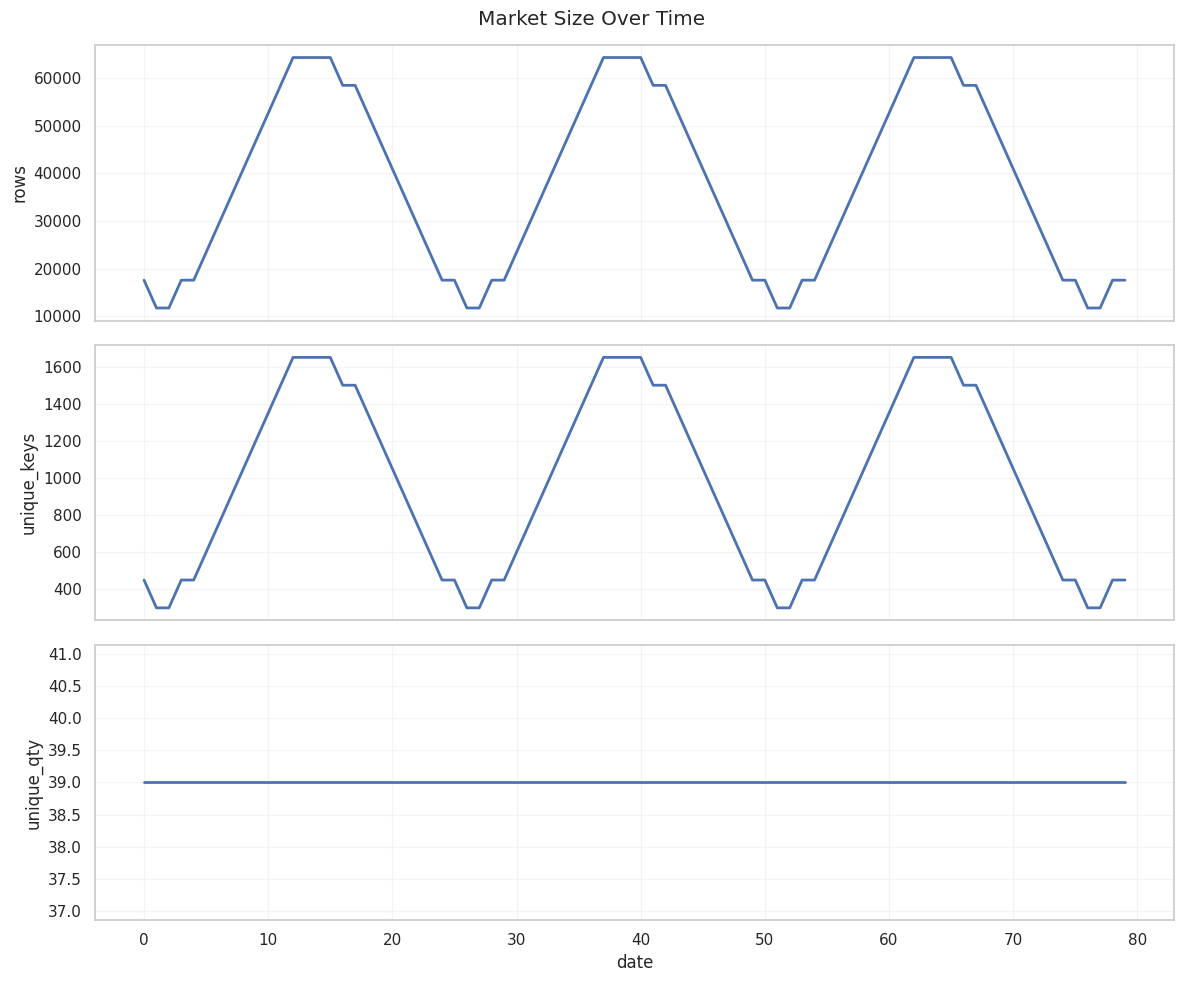

In [11]:
date_size = train_all.groupby("date").agg(
    rows=("qty", "size"),
    unique_keys=("key", "nunique"),
    unique_qty=("qty", "nunique"),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, ["rows", "unique_keys", "unique_qty"]):
    ax.plot(date_size["date"], date_size[col], lw=2)
    ax.set_ylabel(col)
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("date")
fig.suptitle("Market Size Over Time")
plt.tight_layout()

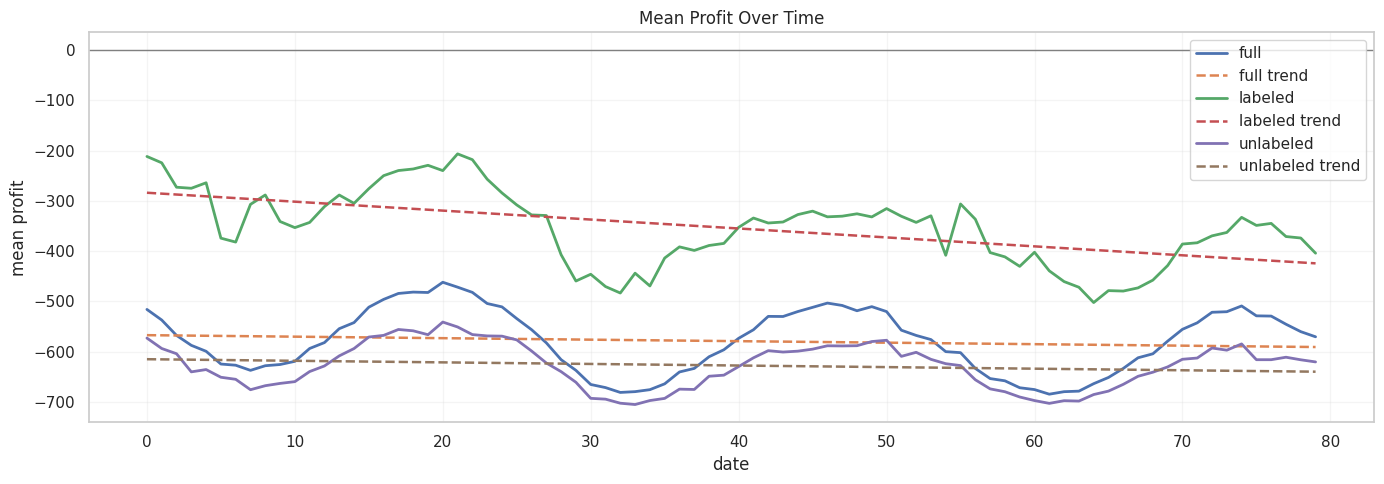

In [12]:
def _plot_trend_overlays(ax, df, col, color):
    segments = config.market_trend_segments or [
        {"start": int(df["date"].min()), "end": int(df["date"].max())}
    ]
    for idx, segment in enumerate(segments):
        seg_df = df[df["date"].between(segment["start"], segment["end"])].copy()
        if len(seg_df) < 2:
            continue
        seg_trend = np.poly1d(np.polyfit(seg_df["date"], seg_df[col], 1))(seg_df["date"])
        ax.plot(
            seg_df["date"],
            seg_trend,
            lw=1.8,
            ls="--",
            color=color,
            label=f"{col} trend" if idx == 0 else None,
        )

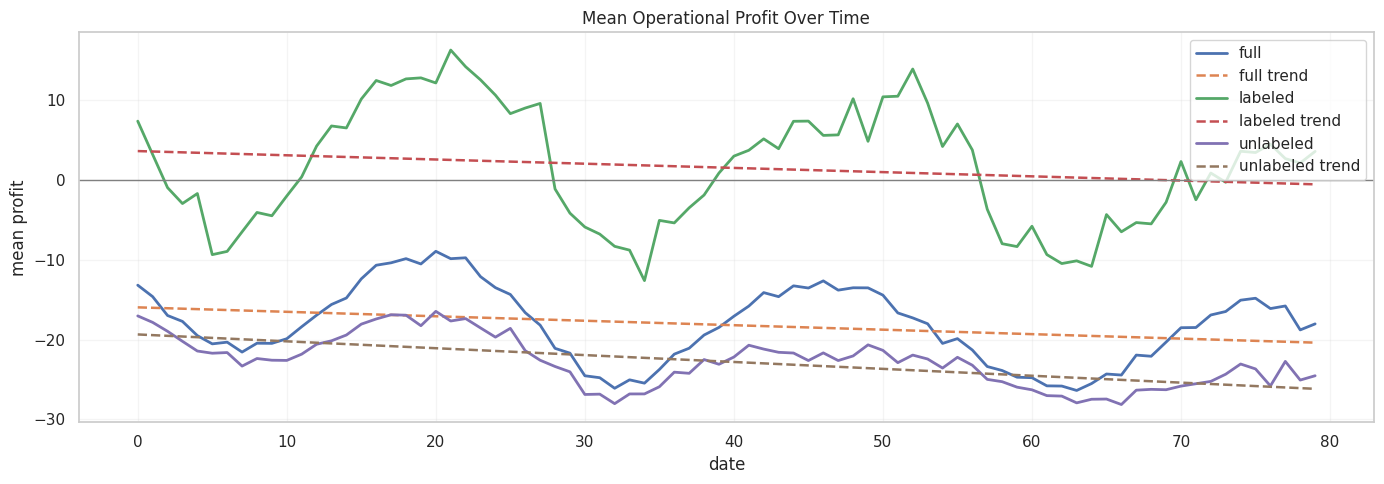

In [13]:
hist_df = bundle["historical_df"].copy()

profit_by_date = hist_df.groupby("date").agg(
    full=("profit", "mean"),
    labeled=("profit", lambda s: s[hist_df.loc[s.index, label_col]].mean()),
    unlabeled=("profit", lambda s: s[~hist_df.loc[s.index, label_col]].mean()),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for col in ["full", "labeled", "unlabeled"]:
    line, = ax.plot(profit_by_date["date"], profit_by_date[col], lw=2, label=col)
    _plot_trend_overlays(ax, profit_by_date, col, line.get_color())
ax.axhline(0, c="gray", lw=1)
ax.set_title("Mean Profit Over Time")
ax.set_xlabel("date")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

In [ ]:
oper_hist_df = bundle["operational_historical_df"].copy()

oper_profit_by_date = oper_hist_df.groupby("date").agg(
    full=("profit", "mean"),
    labeled=("profit", lambda s: s[oper_hist_df.loc[s.index, label_col]].mean()),
    unlabeled=("profit", lambda s: s[~oper_hist_df.loc[s.index, label_col]].mean()),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for col in ["full", "labeled", "unlabeled"]:
    line, = ax.plot(oper_profit_by_date["date"], oper_profit_by_date[col], lw=2, label=col)
    _plot_trend_overlays(ax, oper_profit_by_date, col, line.get_color())
ax.axhline(0, c="gray", lw=1)
ax.set_title("Mean Operational Profit Over Time")
ax.set_xlabel("date")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

In [ ]:
oper_total_profit_by_date = oper_hist_df.groupby("date").agg(
    full=("profit", "sum"),
    labeled=("profit", lambda s: s[oper_hist_df.loc[s.index, label_col]].sum()),
    unlabeled=("profit", lambda s: s[~oper_hist_df.loc[s.index, label_col]].sum()),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for col in ["full", "labeled", "unlabeled"]:
    line, = ax.plot(oper_total_profit_by_date["date"], oper_total_profit_by_date[col], lw=2, label=col)
    _plot_trend_overlays(ax, oper_total_profit_by_date, col, line.get_color())
ax.axhline(0, c="gray", lw=1)
ax.set_title("Total Operational Profit Over Time")
ax.set_xlabel("date")
ax.set_ylabel("total profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

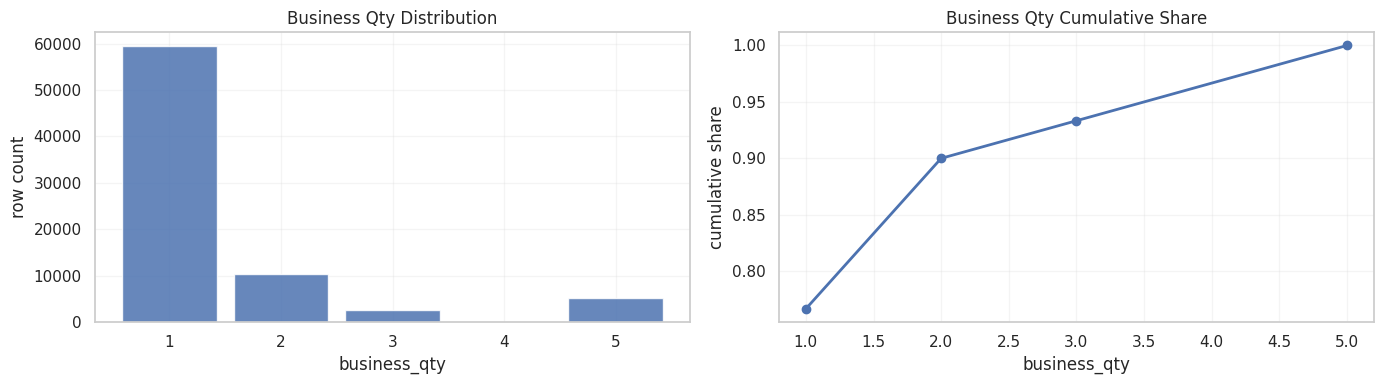

In [14]:
business_qty_df = bundle["generated"]["key_policy_df"][["business_qty"]].copy()
qty_counts = business_qty_df["business_qty"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(qty_counts.index, qty_counts.values, width=0.85, alpha=0.85)
axes[0].set_title("Business Qty Distribution")
axes[0].set_xlabel("business_qty")
axes[0].set_ylabel("row count")
axes[0].grid(alpha=0.2)

axes[1].plot(qty_counts.index, qty_counts.cumsum() / qty_counts.sum(), marker="o", lw=2)
axes[1].set_title("Business Qty Cumulative Share")
axes[1].set_xlabel("business_qty")
axes[1].set_ylabel("cumulative share")
axes[1].grid(alpha=0.2)
plt.tight_layout()

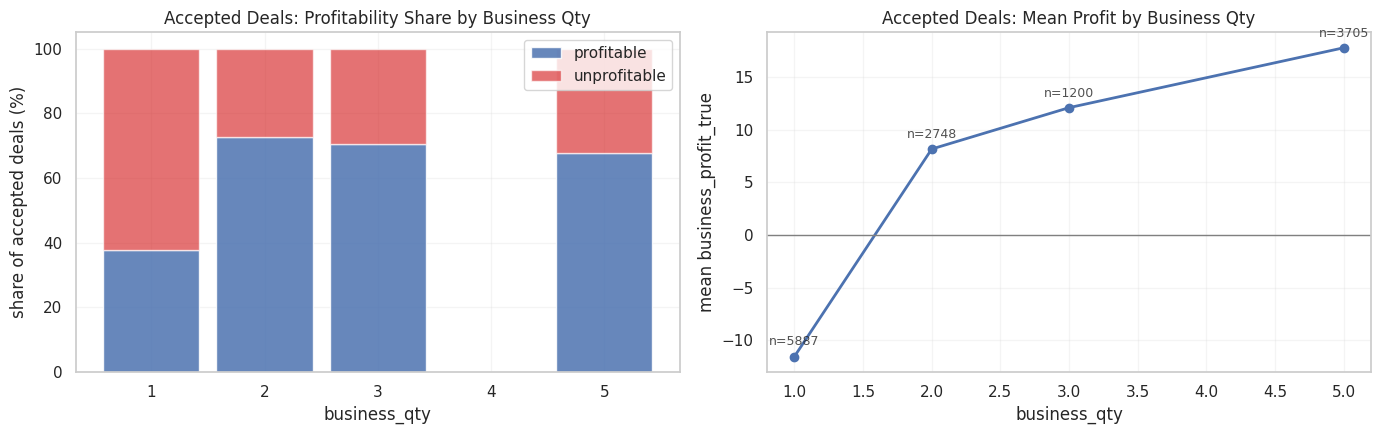

In [15]:
accepted_qty_profit = bundle["generated"]["key_policy_df"].query("accepted").copy()
accepted_qty_profit["profitable"] = accepted_qty_profit["business_profit_true"] > 0

qty_profit_summary = (
    accepted_qty_profit.groupby("business_qty")
    .agg(
        profitable_share=("profitable", "mean"),
        mean_profit=("business_profit_true", "mean"),
        deal_count=("business_qty", "size"),
    )
    .reset_index()
)
qty_profit_summary["unprofitable_share"] = 1.0 - qty_profit_summary["profitable_share"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(
    qty_profit_summary["business_qty"],
    100 * qty_profit_summary["profitable_share"],
    width=0.85,
    label="profitable",
    alpha=0.85,
)
axes[0].bar(
    qty_profit_summary["business_qty"],
    100 * qty_profit_summary["unprofitable_share"],
    bottom=100 * qty_profit_summary["profitable_share"],
    width=0.85,
    label="unprofitable",
    alpha=0.65,
    color="tab:red",
)
axes[0].set_title("Accepted Deals: Profitability Share by Business Qty")
axes[0].set_xlabel("business_qty")
axes[0].set_ylabel("share of accepted deals (%)")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(qty_profit_summary["business_qty"], qty_profit_summary["mean_profit"], marker="o", lw=2)
for _, row in qty_profit_summary.iterrows():
    axes[1].annotate(
        f"n={int(row['deal_count'])}",
        (row["business_qty"], row["mean_profit"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        alpha=0.8,
    )
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_title("Accepted Deals: Mean Profit by Business Qty")
axes[1].set_xlabel("business_qty")
axes[1].set_ylabel("mean business_profit_true")
axes[1].grid(alpha=0.2)
plt.tight_layout()

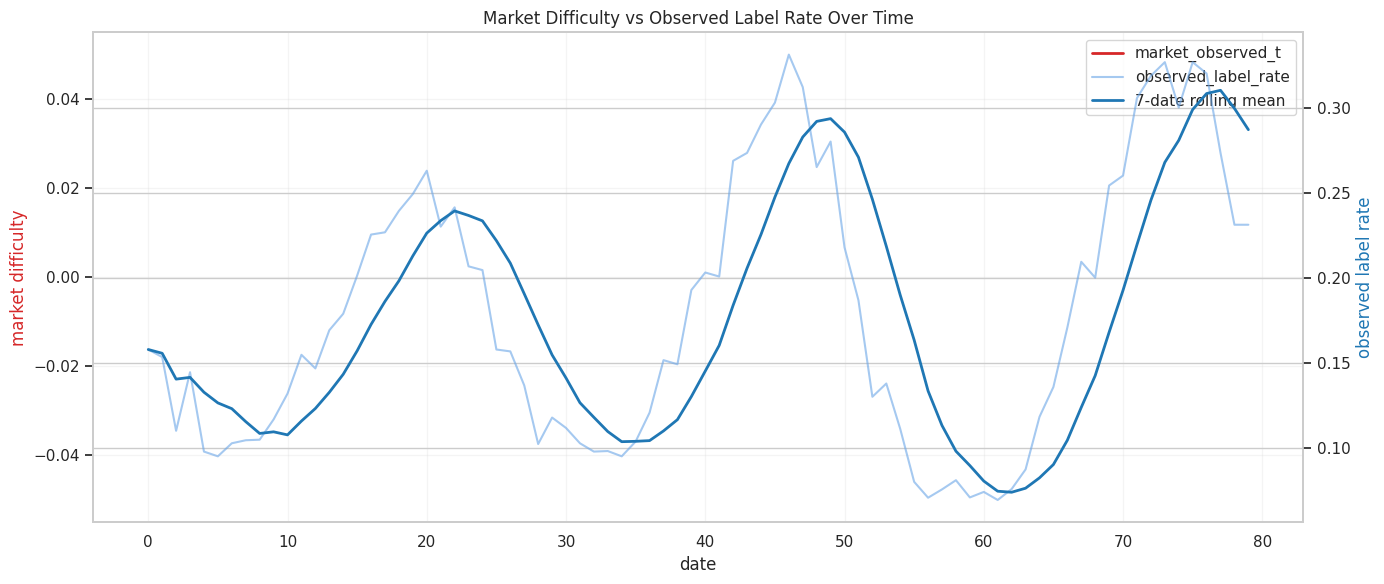

In [16]:
acceptance_by_date = (
    train_all[["date", "key", "segment"]]
    .drop_duplicates(["date", "key"])
    .groupby("date")
    .agg(observed_label_rate=("segment", lambda s: (s == "labeled").mean()))
    .reset_index()
)
acceptance_by_date = acceptance_by_date.merge(date_drivers, on="date", how="left")
acceptance_by_date["rolling_observed_label_rate_7"] = acceptance_by_date["observed_label_rate"].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(acceptance_by_date["date"], acceptance_by_date["market_observed_t"], c="tab:red", lw=2, label="market_observed_t")
ax2.plot(acceptance_by_date["date"], acceptance_by_date["observed_label_rate"], c="#6aa5e7", lw=1.5, alpha=0.6, label="observed_label_rate")
ax2.plot(acceptance_by_date["date"], acceptance_by_date["rolling_observed_label_rate_7"], c="tab:blue", lw=2, label="7-date rolling mean")
ax1.set_title("Market Difficulty vs Observed Label Rate Over Time")
ax1.set_xlabel("date")
ax1.set_ylabel("market difficulty", color="tab:red")
ax2.set_ylabel("observed label rate", color="tab:blue")
ax1.grid(alpha=0.2)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper right")
plt.tight_layout()

In [17]:
_require_generated_inspection_context("Policy-score and latent-driver diagnostics")

kdf = bundle["generated"]["key_policy_df"]
rej = kdf.loc[~kdf["accepted"], "policy_score_true"]
acc = kdf.loc[kdf["accepted"], "policy_score_true"]
thr = kdf["policy_threshold_t"].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, density, ylabel, title in [
    (axes[0], True, "density", "Policy Score (Density)"),
    (axes[1], False, "count", "Policy Score (Counts)"),
]:
    ax.hist(rej, bins=80, alpha=0.6, label="rejected", density=density)
    ax.hist(acc, bins=80, alpha=0.6, label="accepted", density=density)
    ax.axvline(thr, color="red", ls="--", lw=2, label="mean threshold")
    ax.set(title=title, xlabel="policy_score_true", ylabel=ylabel)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

RuntimeError: Policy-score and latent-driver diagnostics requires generator internals that are not saved in exported datasets. Set inspection_data_mode='generated' and rerun the market synth call.

In [18]:
# Idea is:

# acceptance rate changes over time because of two main things:

# market difficulty changes the mix of offers available
# hidden business strictness changes the approval rule

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

acc_df = (
    bundle["historical_df"]
    .groupby("date")["accepted"].mean()
    .rename("acceptance_rate")
    .reset_index()
    .merge(bundle["date_process_df"][["date", "market_observed_t", "policy_threshold_t"]], on="date", how="left")
)

y = acc_df["acceptance_rate"].values
X_market = acc_df[["market_observed_t"]].values
X_policy = acc_df[["policy_threshold_t"]].values
X_both = acc_df[["market_observed_t", "policy_threshold_t"]].values

r2_market = r2_score(y, LinearRegression().fit(X_market, y).predict(X_market))
r2_policy = r2_score(y, LinearRegression().fit(X_policy, y).predict(X_policy))
r2_both = r2_score(y, LinearRegression().fit(X_both, y).predict(X_both))

market_share = 0.5 * ((r2_both - r2_policy) + r2_market)
policy_share = 0.5 * ((r2_both - r2_market) + r2_policy)

print(f"R^2 market only: {r2_market:.3f}")
print(f"R^2 latent business rule only: {r2_policy:.3f}")
print(f"R^2 both: {r2_both:.3f}")
print()
print(f"Percent of explained variance from market difficulty: {100 * market_share / r2_both:.1f}%")
print(f"Percent of explained variance from latent business rule changes: {100 * policy_share / r2_both:.1f}%")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [22]:
policy_hist_df = bundle["key_policy_df"][bundle["key_policy_df"]["date"].isin(bundle["historical_df"]["date"].unique())].copy()
explore_df = policy_hist_df[policy_hist_df["accepted_via_exploration"]].copy()

print(f"Exploration accepts: {len(explore_df):,} / {len(policy_hist_df):,} ({len(explore_df) / len(policy_hist_df):.2%})")
print(f"Exploration share inside accepted deals: {len(explore_df) / policy_hist_df['accepted'].sum():.2%}")
print(f"Target exploration share inside accepted deals: {config.policy_exploration_accept_rate:.2%}")
display(explore_df[["date", "key", "margin", "sv", "policy_gap_to_threshold"]].sort_values("policy_gap_to_threshold", ascending=False).head(10))

explore_by_date = (
    policy_hist_df
    .groupby("date")
    .agg(
        acceptance_rate=("accepted", "mean"),
        exploration_rate=("accepted_via_exploration", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(explore_by_date["date"], 100 * explore_by_date["acceptance_rate"], lw=2, label="accepted")
axes[0].plot(
    explore_by_date["date"],
    100 * explore_by_date["exploration_rate"] / explore_by_date["acceptance_rate"],
    lw=2,
    label="exploration inside accepted",
)
axes[0].axhline(100 * config.policy_exploration_accept_rate, color="black", ls="--", lw=1.5, label="target exploration inside accepted")
axes[0].set_title("Accepted rate vs exploration share inside accepted")
axes[0].set_ylabel("percent of deals")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].hist(explore_df["policy_gap_to_threshold"], bins=20, alpha=0.8)
axes[1].set_title("Exploration deals: gap below policy threshold")
axes[1].set_xlabel("threshold - score")
axes[1].grid(alpha=0.2)
plt.tight_layout()

Exploration accepts: 0 / 77,550 (0.00%)
Exploration share inside accepted deals: 0.00%
Target exploration share inside accepted deals: 1.00%


KeyError: "['margin', 'sv'] not in index"

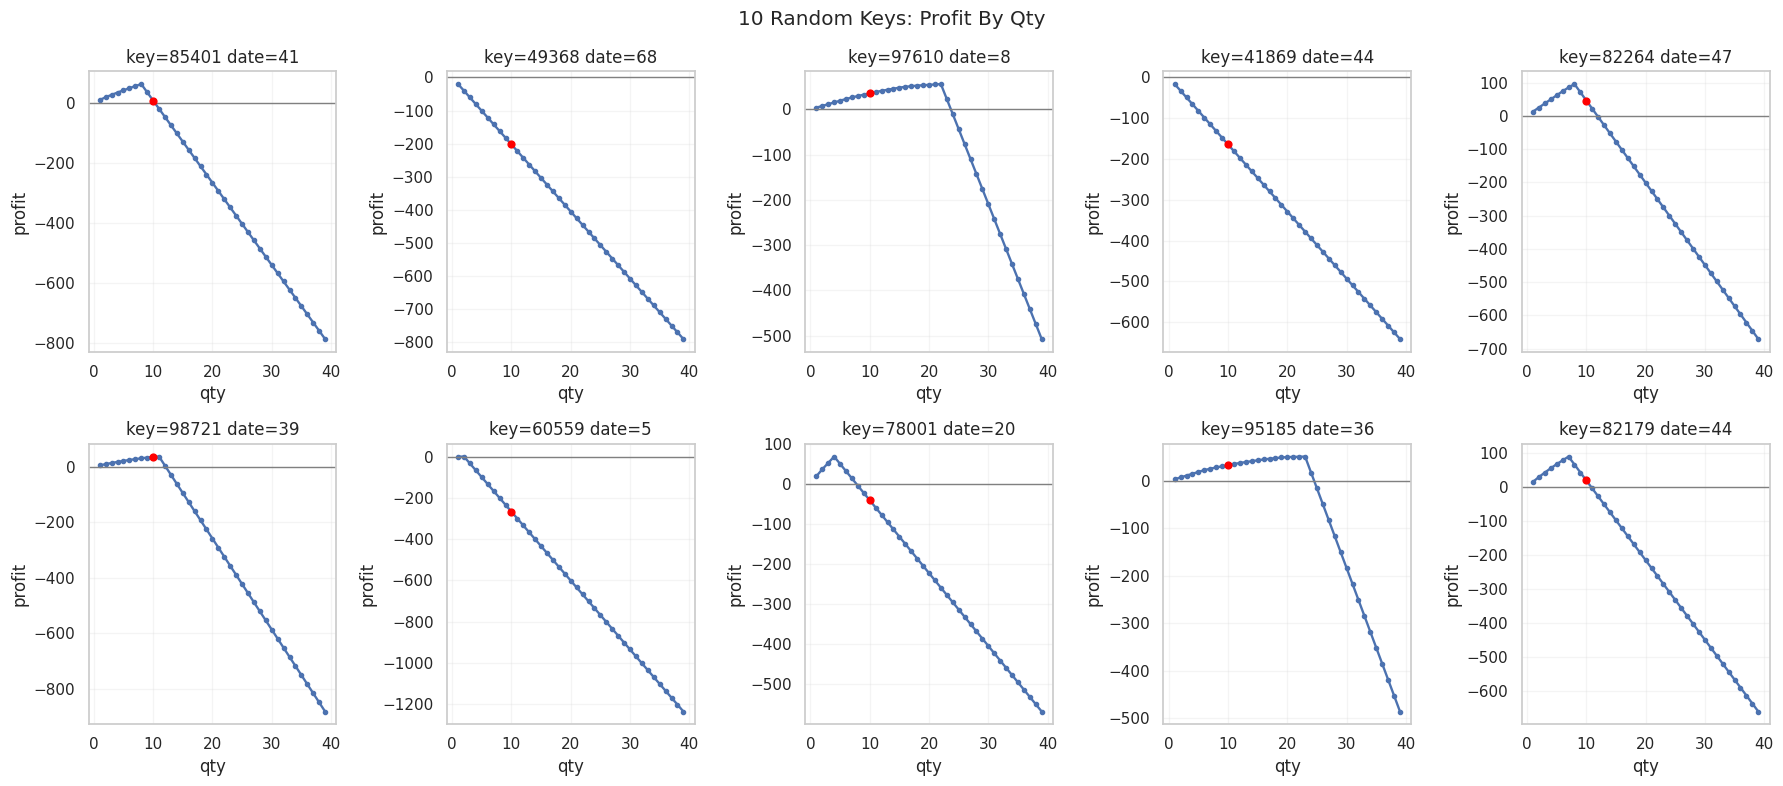

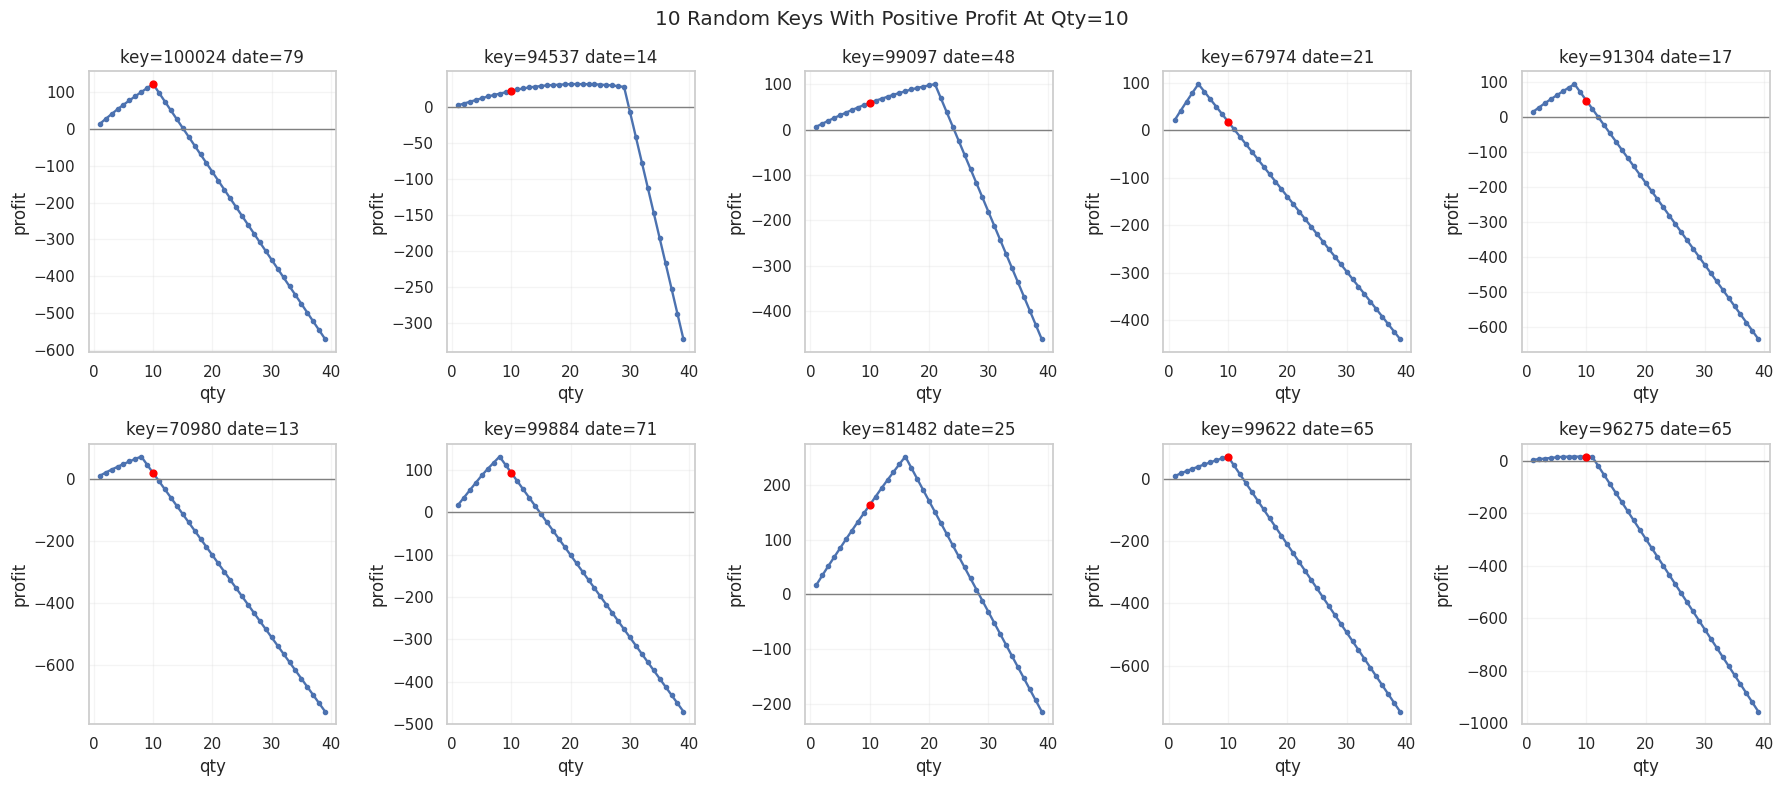

In [20]:
curve_df = train_all[train_all["segment"] == "labeled"].copy()
keys_any = rng.choice(curve_df["key"].drop_duplicates(), size=min(10, curve_df["key"].nunique()), replace=False)
keys_qty10_pos = curve_df[(curve_df["qty"] == 10) & (curve_df["profit"] > 0)]["key"].drop_duplicates()
keys_qty10_pos = rng.choice(keys_qty10_pos, size=min(10, len(keys_qty10_pos)), replace=False) if len(keys_qty10_pos) else np.array([])

fig, axes = plt.subplots(2, 5, figsize=(18, 8), squeeze=False)
for ax, key in zip(axes.ravel(), keys_any):
    key_df = curve_df[curve_df["key"] == key].sort_values("qty")
    ax.plot(key_df["qty"], key_df["profit"], marker="o", ms=3, lw=1.7)
    qty10 = key_df[key_df["qty"] == 10]
    if len(qty10):
        ax.scatter(qty10["qty"], qty10["profit"], c="red", s=24, zorder=3)
    ax.axhline(0, c="gray", lw=1)
    ax.set_title(f"key={int(key)} date={int(key_df['date'].iloc[0])}")
    ax.set_xlabel("qty")
    ax.set_ylabel("profit")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(keys_any):]:
    ax.axis("off")
fig.suptitle("10 Random Keys: Profit By Qty")
plt.tight_layout()



fig, axes = plt.subplots(2, 5, figsize=(18, 8), squeeze=False)
for ax, key in zip(axes.ravel(), keys_qty10_pos):
    key_df = curve_df[curve_df["key"] == key].sort_values("qty")
    ax.plot(key_df["qty"], key_df["profit"], marker="o", ms=3, lw=1.7)
    qty10 = key_df[key_df["qty"] == 10]
    if len(qty10):
        ax.scatter(qty10["qty"], qty10["profit"], c="red", s=24, zorder=3)
    ax.axhline(0, c="gray", lw=1)
    ax.set_title(f"key={int(key)} date={int(key_df['date'].iloc[0])}")
    ax.set_xlabel("qty")
    ax.set_ylabel("profit")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(keys_qty10_pos):]:
    ax.axis("off")
fig.suptitle("10 Random Keys With Positive Profit At Qty=10")
plt.tight_layout()

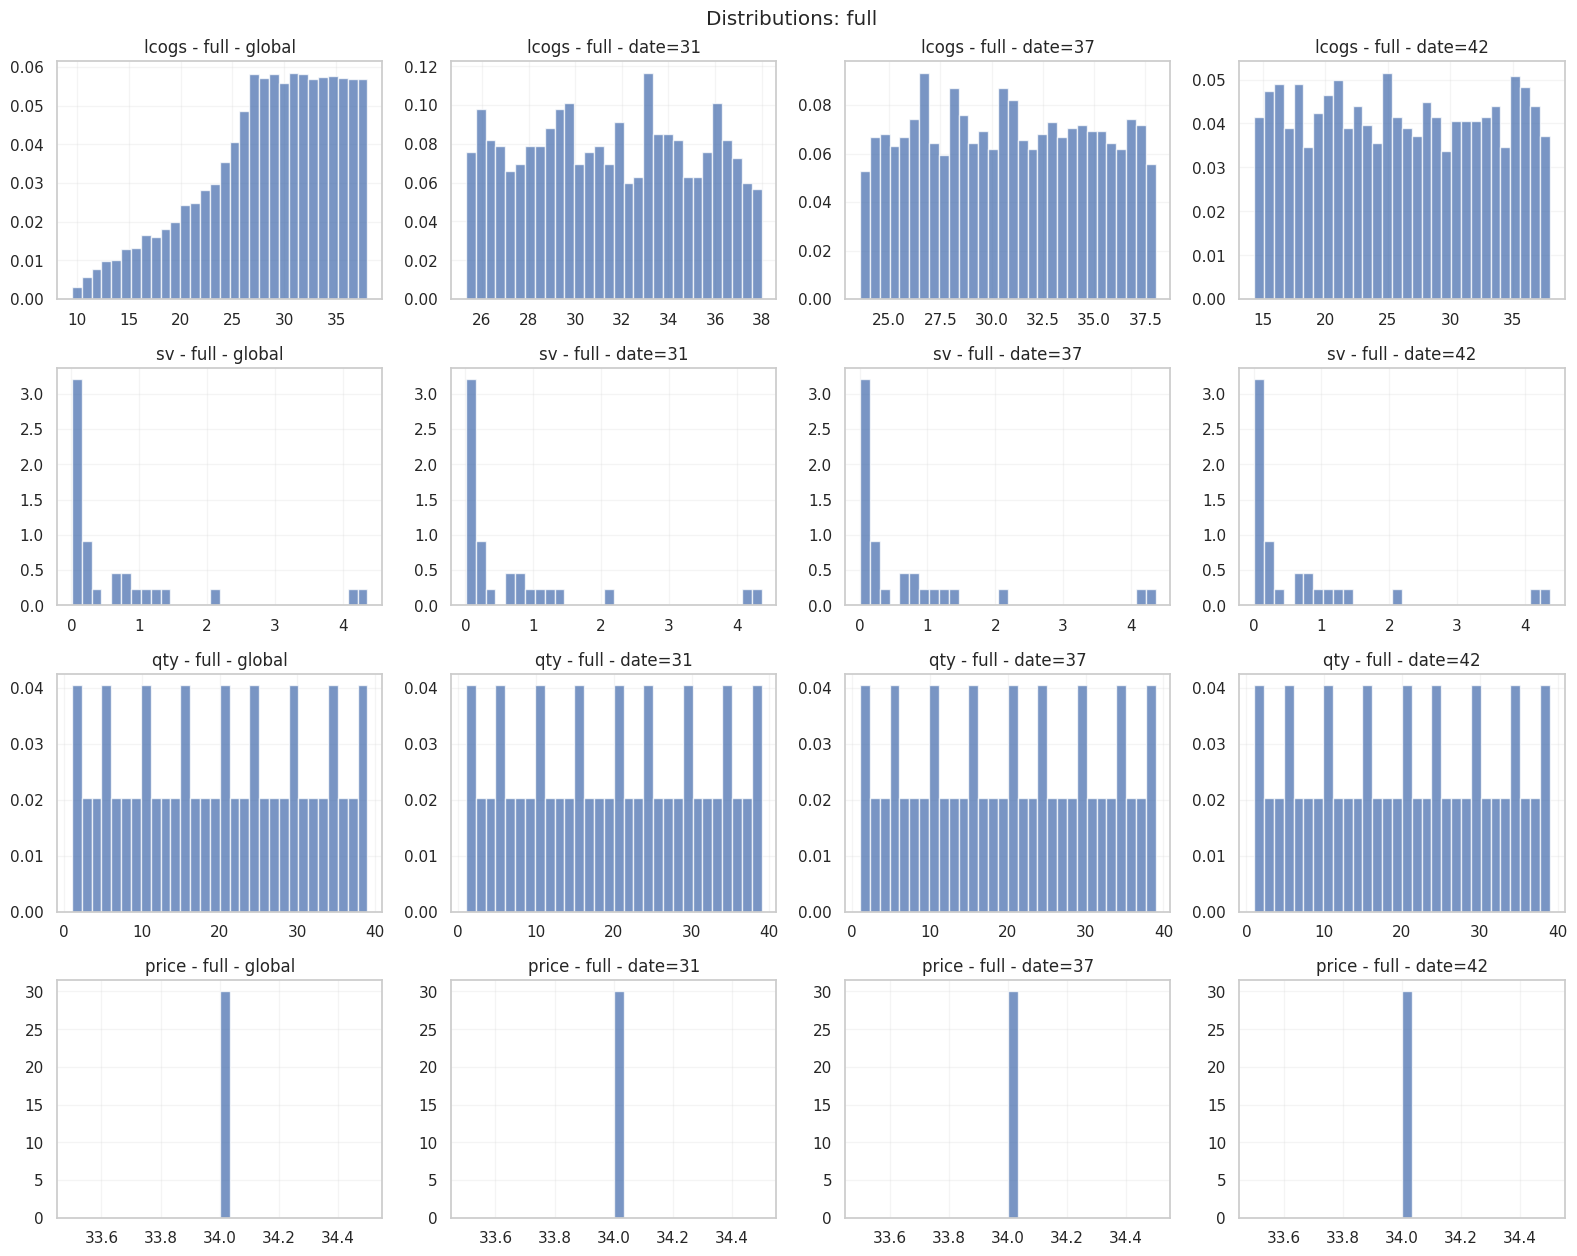

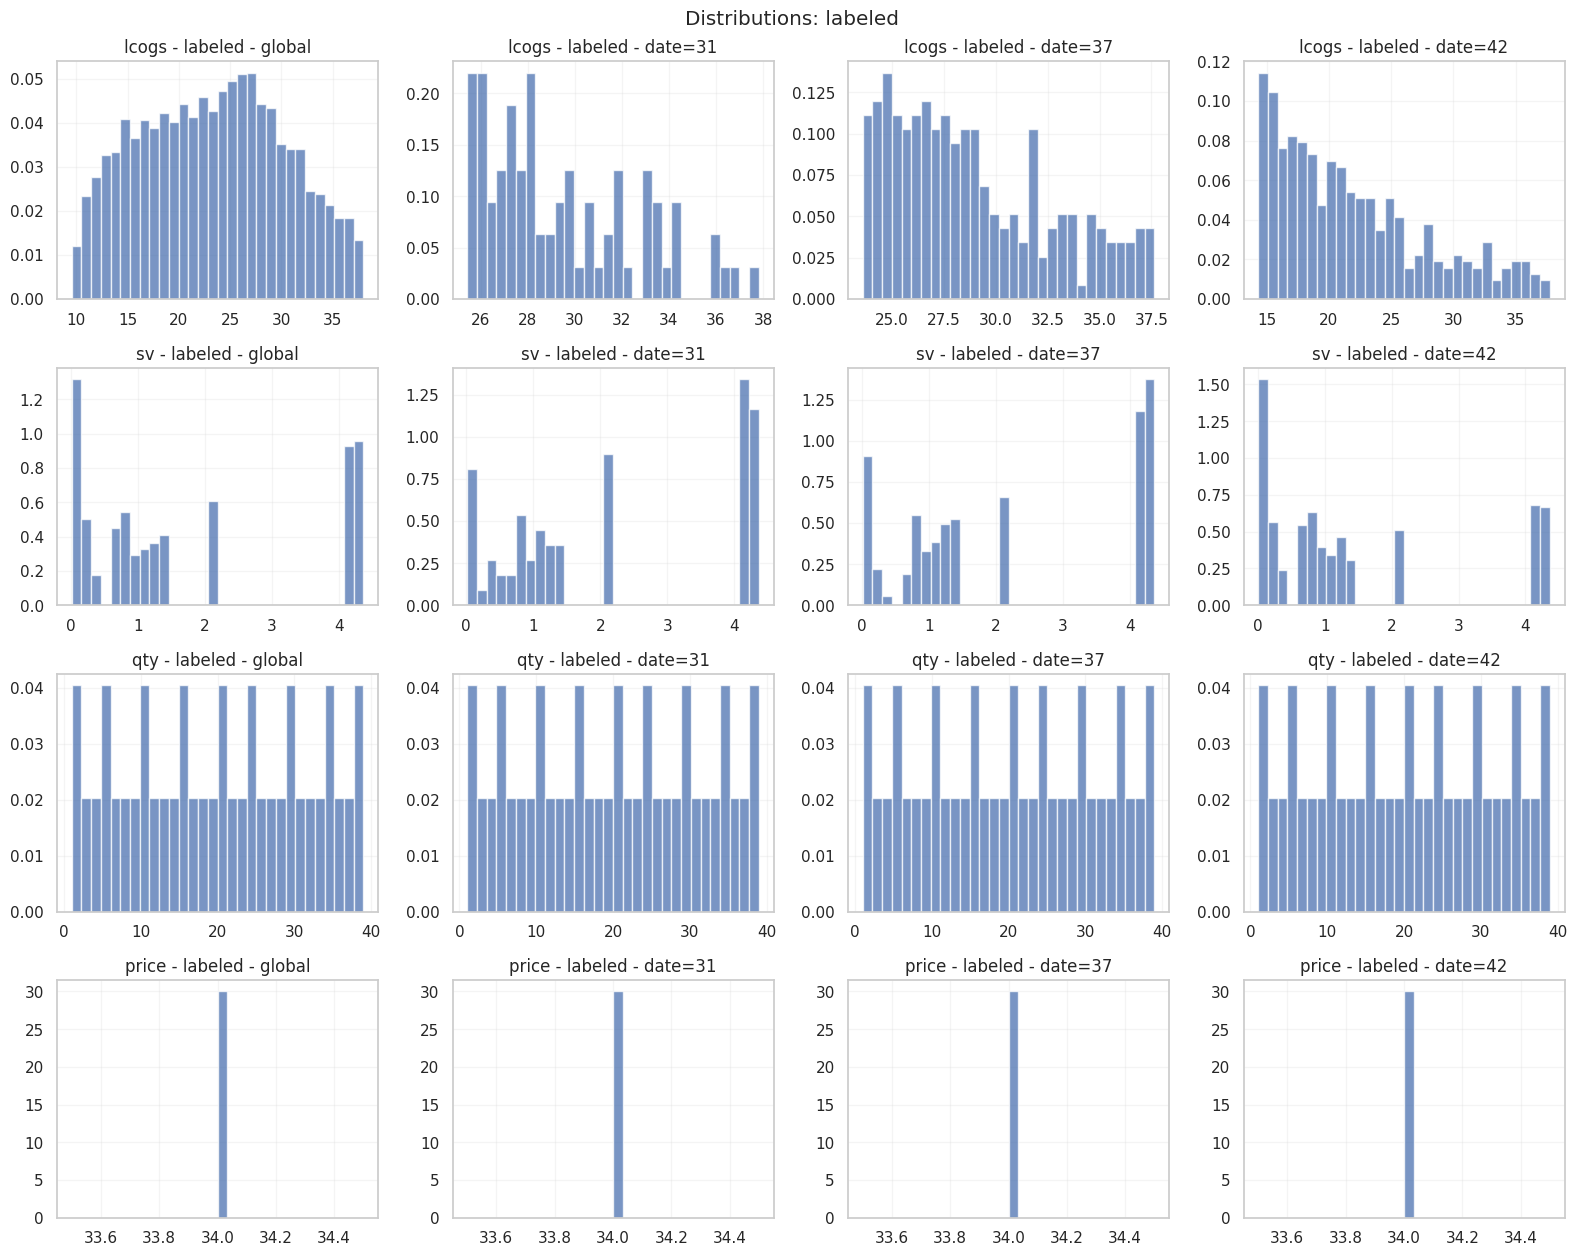

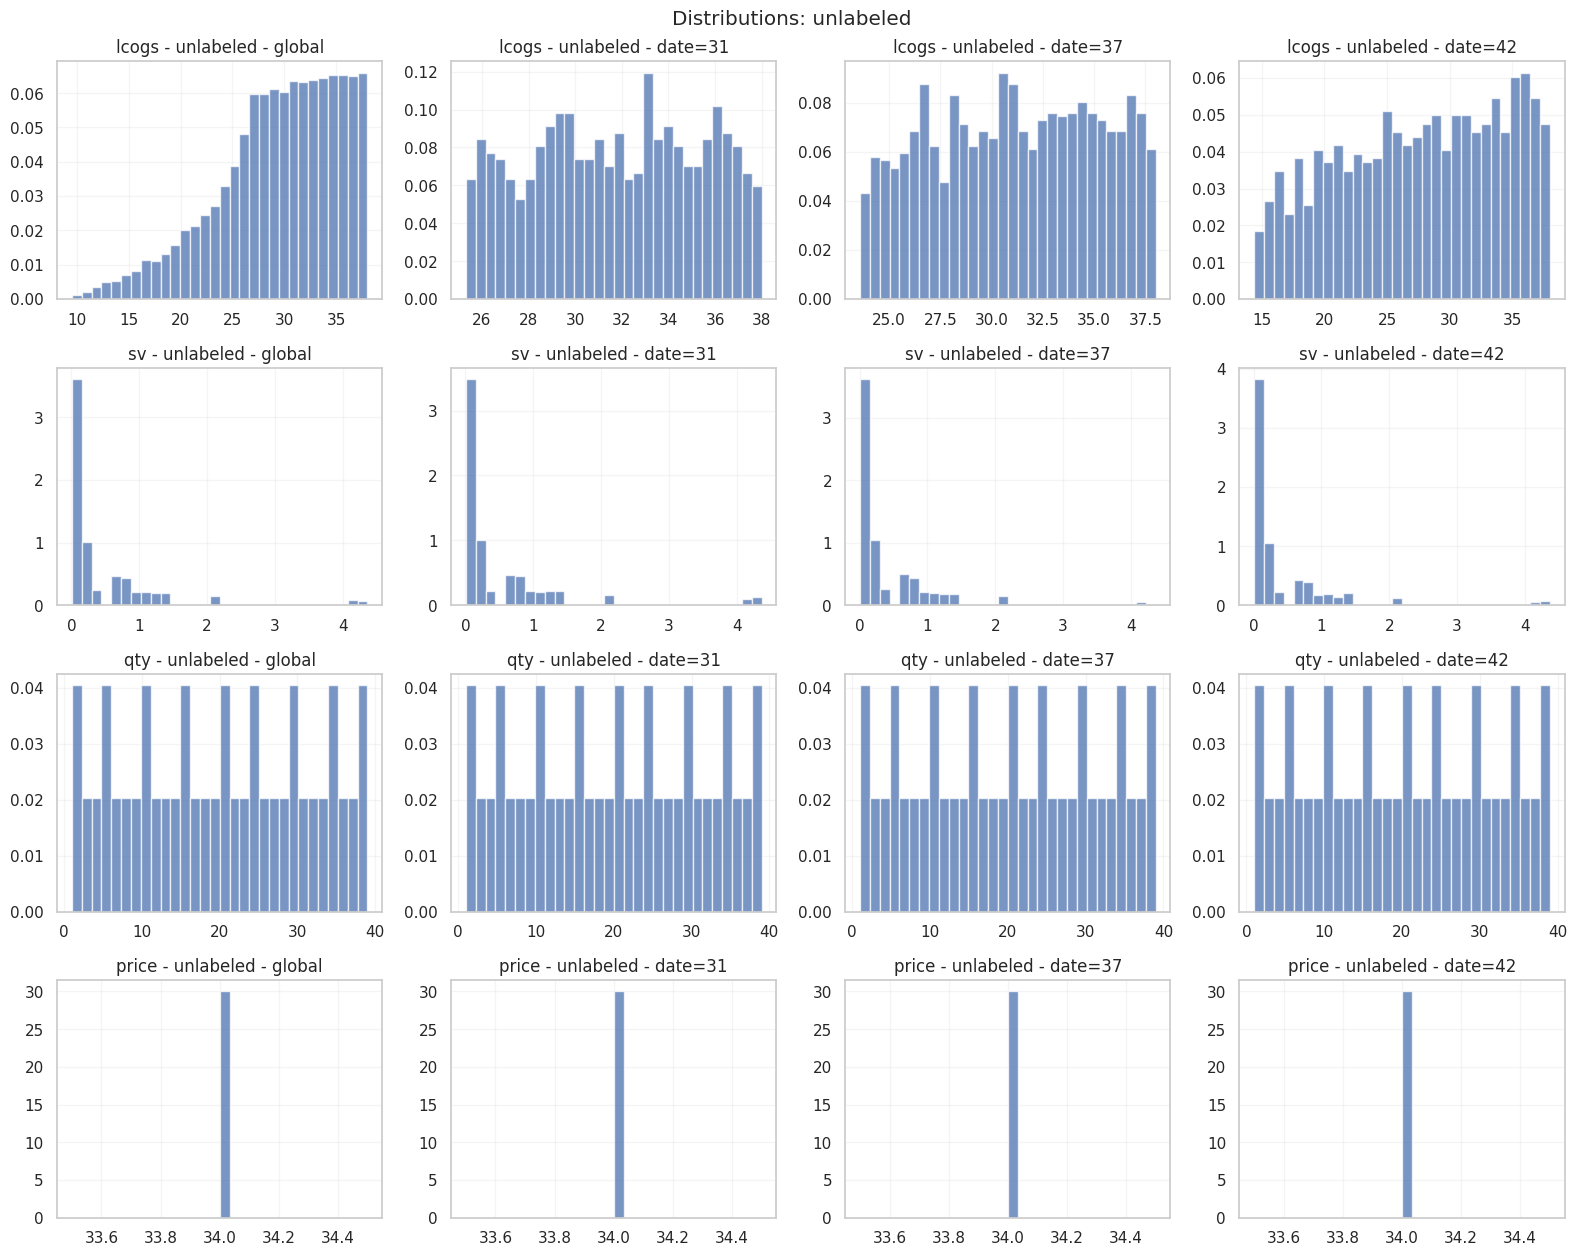

In [21]:
dates_3 = rng.choice(np.sort(train_all["date"].unique()), size=min(3, train_all["date"].nunique()), replace=False)
plot_df = pd.concat([train_all.assign(slice="global"), train_all[train_all["date"].isin(dates_3)].assign(slice=lambda d: "date=" + d["date"].astype(int).astype(str))], ignore_index=True)
features = ["lcogs", "sv", "qty", "price"]

for segment in ["full", "labeled", "unlabeled"]:
    fig, axes = plt.subplots(len(features), 4, figsize=(16, 3.2 * len(features)), squeeze=False)
    seg_df = plot_df if segment == "full" else plot_df[plot_df["segment"] == segment]
    for i, feature in enumerate(features):
        for j, slice_name in enumerate(["global"] + [f"date={int(x)}" for x in dates_3]):
            ax = axes[i, j]
            ax.hist(seg_df.loc[seg_df["slice"] == slice_name, feature], bins=30, alpha=0.75, density=True)
            ax.set_title(f"{feature} - {segment} - {slice_name}")
            ax.grid(alpha=0.2)
    fig.suptitle(f"Distributions: {segment}")
    plt.tight_layout()

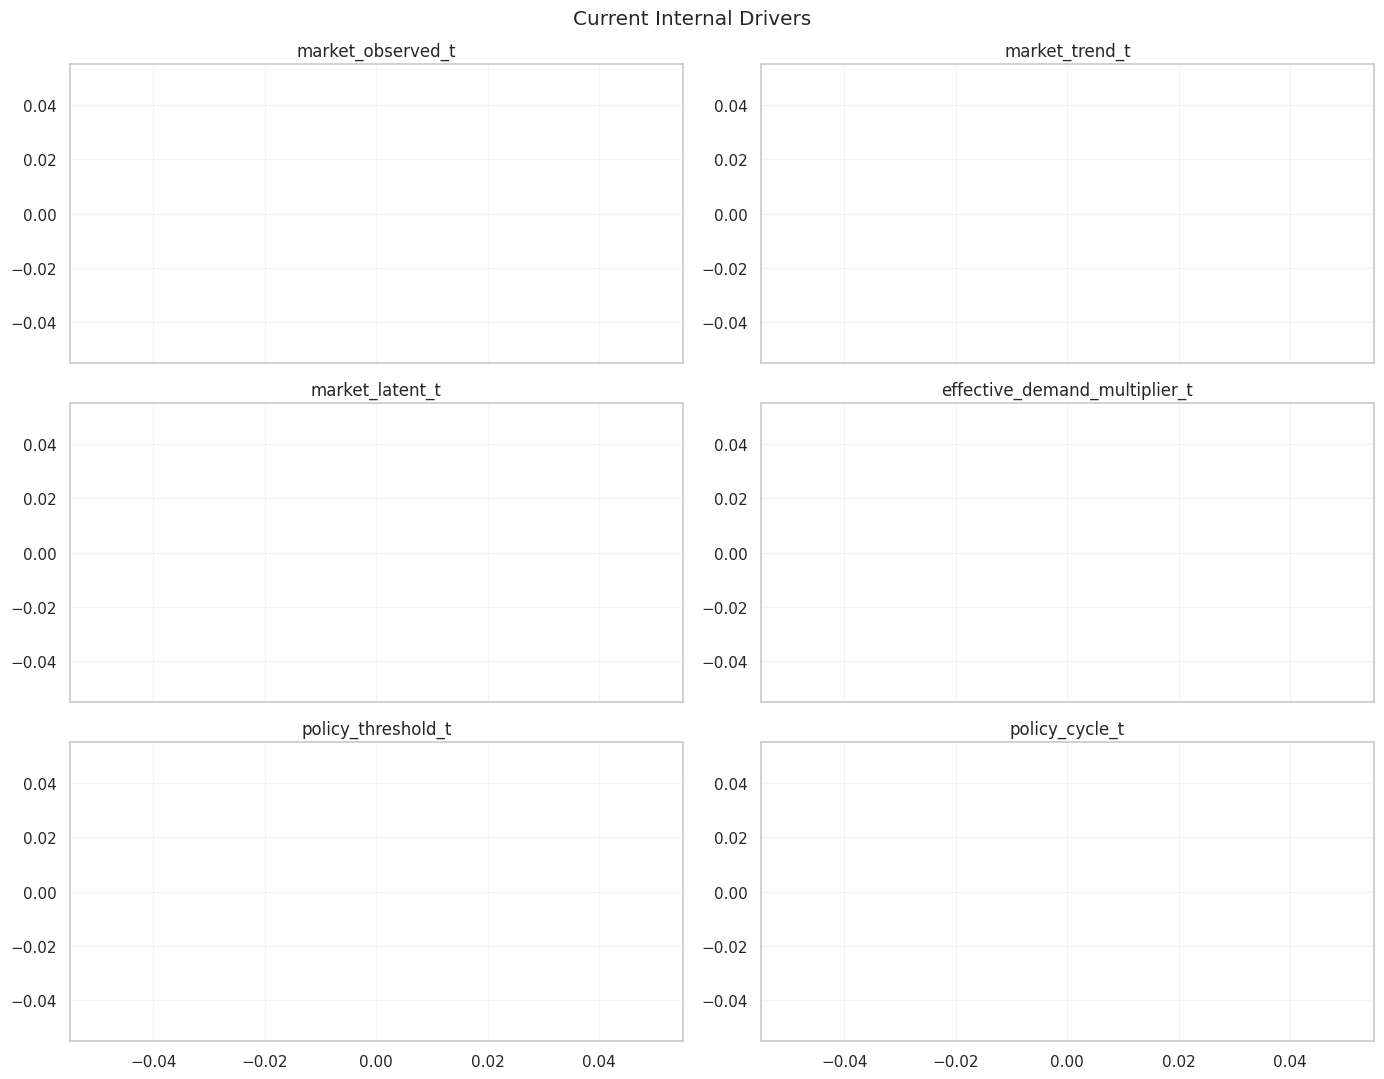

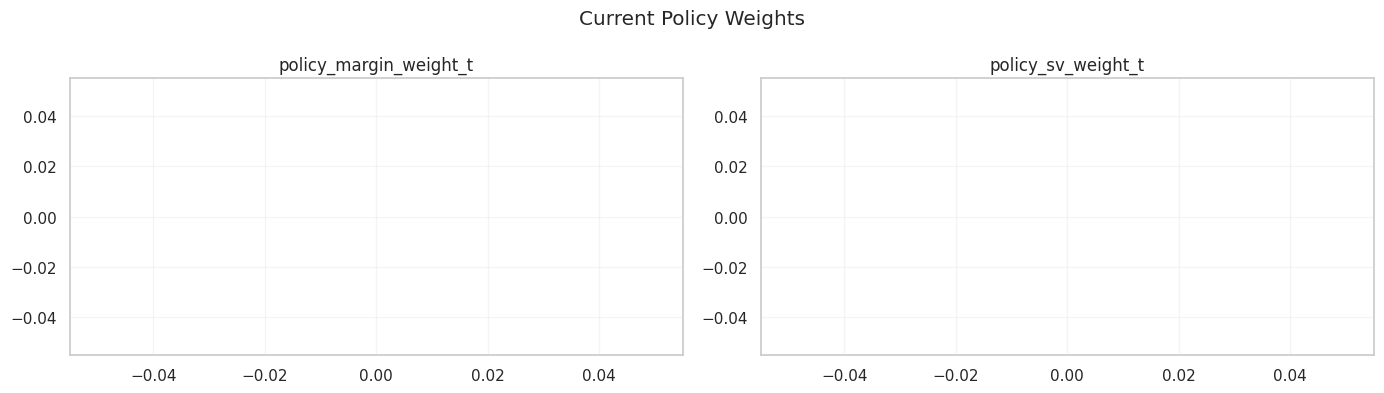

In [23]:
driver_df = bundle["date_process_df"].copy()
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for ax, col in zip(axes.ravel(), ["market_observed_t", "market_trend_t", "market_latent_t", "effective_demand_multiplier_t", "policy_threshold_t", "policy_cycle_t"]):
    ax.plot(driver_df["date"], driver_df[col], lw=2)
    ax.set_title(col)
    ax.grid(alpha=0.2)
fig.suptitle("Current Internal Drivers")
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, col in zip(axes.ravel(), ["policy_margin_weight_t", "policy_sv_weight_t"]):
    ax.plot(driver_df["date"], driver_df[col], lw=2)
    ax.set_title(f"{col}")
    ax.grid(alpha=0.2)
fig.suptitle("Current Policy Weights")
plt.tight_layout()

In [24]:
expected_qtys = set(sorted(train_all["qty"].unique()))
expected_n_qty = len(expected_qtys)

print(f"Expected qty count per key: {expected_n_qty}")
print(f"Expected qty range: {min(expected_qtys)}..{max(expected_qtys)}")

biased_check = pd.concat(
    [
        x_grounded_biased_keys.reset_index(drop=True),
        x_grounded_biased_dates.reset_index(drop=True),
        X_grounded_biased[["qty"]].reset_index(drop=True),
    ],
    axis=1,
)

unlabeled_check = pd.concat(
    [
        x_grounded_deployment_unlabeled_keys.reset_index(drop=True),
        x_grounded_deployment_unlabeled_dates.reset_index(drop=True),
        X_grounded_deployment_unlabeled[["qty"]].reset_index(drop=True),
    ],
    axis=1,
)

biased_qty_counts = biased_check.groupby("key")["qty"].nunique()
unlabeled_qty_counts = unlabeled_check.groupby("key")["qty"].nunique()
combined_check = pd.concat(
    [
        biased_check.assign(segment="labeled"),
        unlabeled_check.assign(segment="unlabeled"),
    ],
    ignore_index=True,
)
combined_qty_counts = combined_check.groupby("key")["qty"].nunique()
bad_combined_keys = combined_qty_counts[combined_qty_counts != expected_n_qty]

if len(bad_combined_keys):
    display(
        combined_check[combined_check["key"].isin(bad_combined_keys.index)]
        .groupby(["key", "segment"])["qty"]
        .agg(list)
        .head(20)
    )

assert len(bad_combined_keys) == 0, f"combined split has {len(bad_combined_keys)} keys with incomplete qty coverage"

print(f"labeled keys checked: {biased_qty_counts.index.nunique():,}")
print(f"unlabeled keys checked: {unlabeled_qty_counts.index.nunique():,}")
print(f"combined keys checked: {combined_qty_counts.index.nunique():,}")
print("OK: labeled + unlabeled still cover the full qty range per key")

Expected qty count per key: 39
Expected qty range: 1.0..39.0
labeled keys checked: 13,540
unlabeled keys checked: 64,010
combined keys checked: 77,550
OK: labeled + unlabeled still cover the full qty range per key


In [25]:
hist_df = bundle["historical_df"]

labeled_pos_rate = (hist_df.loc[hist_df[label_col], "profit"] > 0).mean()
unlabeled_pos_rate = (hist_df.loc[~hist_df[label_col], "profit"] > 0).mean()

print(f"labeled y>0 rate: {100 * labeled_pos_rate:.2f}%")
print(f"unlabeled y>0 rate: {100 * unlabeled_pos_rate:.2f}%")

labeled y>0 rate: 19.23%
unlabeled y>0 rate: 2.58%


In [26]:
hist_df = bundle["historical_df"]
hist_df_q2 = hist_df[hist_df["qty"] == 2]

labeled_pos_rate_q2 = (hist_df_q2.loc[hist_df_q2[label_col], "profit"] > 0).mean()
unlabeled_pos_rate_q2 = (hist_df_q2.loc[~hist_df_q2[label_col], "profit"] > 0).mean()

print(f"qty=2 labeled y>0 rate: {100 * labeled_pos_rate_q2:.2f}%")
print(f"qty=2 unlabeled y>0 rate: {100 * unlabeled_pos_rate_q2:.2f}%")

qty=2 labeled y>0 rate: 58.51%
qty=2 unlabeled y>0 rate: 16.13%


In [27]:
_require_generated_inspection_context("Controlled profit-draw diagnostics")

probe_qtys = [qty for qty in [10, 20, 29] if (hist_df["qty"] == qty).any()]
assert len(probe_qtys) > 0, "Need at least one probe qty present in hist_df"
date_multiplier = bundle["date_process_df"].set_index("date")["effective_demand_multiplier_t"]
profit_draws_per_deal = 256


def simulate_offer_profit_draws(row, offer_fragility: float | None = None, n_draws: int = 256):
    sigma = bundle["generated"]["SIGMAS"][int(row.sku_cluster)]
    sampler = bundle["generated"]["SAMPLERS"][int(row.sku_cluster)]
    sv_effective = float(row.sv) * float(date_multiplier.loc[row.date])
    inventory_cost_basis = _inventory_cost_basis(
        lcogs=row.lcogs,
        qty_ordered=row.qty,
    )
    fragility = float(row.latent_offer_fragility) if offer_fragility is None else float(offer_fragility)
    profits = []
    downside_regime_hits = 0
    downside_regime_prob = np.nan
    for _ in range(n_draws):
        weekly_demand_path = _generate_weekly_demand_path(
            sv_effective=sv_effective,
            raw_rel_sigma=sigma,
            sampler=sampler,
            config=config,
            n_weeks=int(config.weekly_demand_n_weeks),
        )
        downside_regime = _sample_offer_downside_regime(
            offer_fragility=fragility,
            config=config,
        )
        weekly_demand_path = _apply_offer_downside_to_weekly_demand_path(
            weekly_demand_path=weekly_demand_path,
            downside_regime=downside_regime,
        )
        profit_draw, _, _ = _simulate_profit_for_weekly_demand_path(
            weekly_demand_path=weekly_demand_path,
            price=row.price,
            lcogs=row.lcogs,
            qty_ordered=row.qty,
            config=config,
        )
        profit_draw, _ = _apply_offer_downside_extra_cost(
            profit_before_downside=profit_draw,
            inventory_cost_basis=inventory_cost_basis,
            downside_regime=downside_regime,
        )
        profits.append(profit_draw)
        downside_regime_hits += int(downside_regime["downside_regime_triggered"])
        downside_regime_prob = float(downside_regime["downside_regime_prob"])
    profits = np.asarray(profits, dtype=float)
    median_profit = float(np.median(profits))
    q10_profit = float(np.quantile(profits, 0.10))
    return {
        "mean_profit": float(profits.mean()),
        "median_profit": median_profit,
        "q10_profit": q10_profit,
        "mean_minus_q10": float(profits.mean() - q10_profit),
        "median_minus_q10": float(median_profit - q10_profit),
        "mean_return": float(profits.mean() / inventory_cost_basis),
        "median_return": float(median_profit / inventory_cost_basis),
        "q10_return": float(q10_profit / inventory_cost_basis),
        "gap_return": float((profits.mean() - q10_profit) / inventory_cost_basis),
        "median_gap_return": float((median_profit - q10_profit) / inventory_cost_basis),
        "downside_regime_hit_rate": float(downside_regime_hits / n_draws),
        "downside_regime_prob": float(downside_regime_prob),
        "inventory_cost_basis": float(inventory_cost_basis),
    }


fragility_grid = np.linspace(0.05, 0.95, 7)
all_controlled_diag = []
all_population_diag = []
all_population_summary = []
qty_summaries = []

for probe_qty in probe_qtys:
    probe_candidates = hist_df[hist_df["qty"] == probe_qty].copy()
    assert len(probe_candidates) > 0, "probe_candidates must not be empty"
    probe_candidates["edge_bucket"] = pd.qcut(
        probe_candidates["latent_offer_edge"].rank(method="first"),
        q=3,
        labels=["weak_edge", "mid_edge", "strong_edge"],
        duplicates="drop",
    )

    template_rows = []
    for edge_bucket, edge_bucket_df in probe_candidates.groupby("edge_bucket", observed=False):
        if len(edge_bucket_df) == 0:
            continue
        edge_bucket_df = edge_bucket_df.assign(
            fragility_distance=(edge_bucket_df["latent_offer_fragility"] - 0.50).abs()
        )
        template_row = edge_bucket_df.sort_values("fragility_distance").iloc[0].copy()
        template_row["edge_bucket"] = edge_bucket
        template_rows.append(template_row)
    template_df = pd.DataFrame(template_rows).reset_index(drop=True)
    assert len(template_df) >= 2, "Need at least 2 template offers for the controlled downside proof"

    controlled_rows = []
    for template_idx, row in template_df.iterrows():
        template_label = (
            f"{row['edge_bucket']} "
            f"(key={int(row['key'])}, date={int(row['date'])}, edge={row['latent_offer_edge']:.2f})"
        )
        for fragility in fragility_grid:
            sim_out = simulate_offer_profit_draws(
                row=row,
                offer_fragility=float(fragility),
                n_draws=profit_draws_per_deal,
            )
            controlled_rows.append({
                "probe_qty": int(probe_qty),
                "template_idx": int(template_idx),
                "template_label": template_label,
                "edge_bucket": row["edge_bucket"],
                "key": float(row["key"]),
                "date": float(row["date"]),
                "latent_offer_edge": float(row["latent_offer_edge"]),
                "base_latent_offer_fragility": float(row["latent_offer_fragility"]),
                "offer_fragility": float(fragility),
                **sim_out,
            })

    controlled_diag = pd.DataFrame(controlled_rows)
    assert len(controlled_diag) > 0, "controlled_diag must not be empty"
    controlled_gap_summary = (
        controlled_diag
        .groupby(["template_idx", "template_label"], as_index=False)
        .agg(
            probe_qty=("probe_qty", "first"),
            edge_bucket=("edge_bucket", "first"),
            key=("key", "first"),
            date=("date", "first"),
            latent_offer_edge=("latent_offer_edge", "first"),
            base_latent_offer_fragility=("base_latent_offer_fragility", "first"),
            corr_fragility_gap=("gap_return", lambda s: float(pd.Series(fragility_grid).corr(pd.Series(s).reset_index(drop=True)))),
            corr_fragility_median_gap=("median_gap_return", lambda s: float(pd.Series(fragility_grid).corr(pd.Series(s).reset_index(drop=True)))),
            corr_fragility_neg_q10=("q10_return", lambda s: float(pd.Series(fragility_grid).corr(-pd.Series(s).reset_index(drop=True)))),
            gap_gain=("gap_return", lambda s: float(pd.Series(s).iloc[-1] - pd.Series(s).iloc[0])),
            median_gap_gain=("median_gap_return", lambda s: float(pd.Series(s).iloc[-1] - pd.Series(s).iloc[0])),
        )
        .sort_values("template_idx")
        .reset_index(drop=True)
    )
    controlled_gap_pass = bool((controlled_gap_summary["corr_fragility_gap"] >= 0.75).all())
    controlled_q10_pass = bool((controlled_gap_summary["corr_fragility_neg_q10"] >= 0.75).all())
    controlled_gain_pass = bool((controlled_gap_summary["gap_gain"] > 0.10).all())
    controlled_verdict = bool(controlled_gap_pass and controlled_q10_pass and controlled_gain_pass)

    probe_candidates["fragility_bucket"] = pd.qcut(
        probe_candidates["latent_offer_fragility"].rank(method="first"),
        q=min(8, len(probe_candidates)),
        labels=False,
        duplicates="drop",
    )
    assert probe_candidates["fragility_bucket"].nunique() >= 4, "Need at least 4 fragility buckets for population inspection"

    population_sample_parts = []
    for _, fragility_bucket_df in probe_candidates.groupby("fragility_bucket"):
        population_sample_parts.append(
            fragility_bucket_df.sample(
                n=min(10, len(fragility_bucket_df)),
                random_state=inspection_seed,
            )
        )
    population_sample = pd.concat(population_sample_parts, ignore_index=True)
    assert len(population_sample) > 0, "population_sample must not be empty"

    population_rows = []
    for row in population_sample.itertuples(index=False):
        sim_out = simulate_offer_profit_draws(
            row=row,
            offer_fragility=float(row.latent_offer_fragility),
            n_draws=profit_draws_per_deal,
        )
        population_rows.append({
            "probe_qty": int(probe_qty),
            "key": row.key,
            "date": row.date,
            "qty": row.qty,
            "fragility_bucket": int(row.fragility_bucket),
            "latent_offer_edge": float(row.latent_offer_edge),
            "latent_offer_fragility": float(row.latent_offer_fragility),
            **sim_out,
        })

    population_diag = pd.DataFrame(population_rows)
    assert len(population_diag) > 0, "population_diag must not be empty"
    population_summary = (
        population_diag
        .groupby("fragility_bucket", as_index=False)
        .agg(
            probe_qty=("probe_qty", "first"),
            latent_offer_fragility=("latent_offer_fragility", "median"),
            latent_offer_edge=("latent_offer_edge", "median"),
            mean_return=("mean_return", "mean"),
            median_return=("median_return", "mean"),
            q10_return=("q10_return", "mean"),
            gap_return=("gap_return", "mean"),
            median_gap_return=("median_gap_return", "mean"),
            downside_regime_hit_rate=("downside_regime_hit_rate", "mean"),
            deals=("key", "size"),
        )
        .sort_values("latent_offer_fragility")
        .reset_index(drop=True)
    )
    population_gap_corr = float(population_diag["latent_offer_fragility"].corr(population_diag["gap_return"]))
    population_median_gap_corr = float(population_diag["latent_offer_fragility"].corr(population_diag["median_gap_return"]))
    population_q10_corr = float(population_diag["latent_offer_fragility"].corr(-population_diag["q10_return"]))
    population_gap_gain = float(population_summary["gap_return"].iloc[-1] - population_summary["gap_return"].iloc[0])
    population_median_gap_gain = float(population_summary["median_gap_return"].iloc[-1] - population_summary["median_gap_return"].iloc[0])
    population_verdict = bool((population_gap_corr > 0.60) and (population_q10_corr > 0.70) and (population_gap_gain > 0.20))

    qty_summaries.append({
        "probe_qty": int(probe_qty),
        "controlled_templates": int(len(template_df)),
        "population_deals_resimulated": int(len(population_diag)),
        "controlled_verdict": controlled_verdict,
        "population_verdict": population_verdict,
        "population_gap_corr": population_gap_corr,
        "population_median_gap_corr": population_median_gap_corr,
        "population_q10_corr": population_q10_corr,
        "population_gap_gain": population_gap_gain,
        "population_median_gap_gain": population_median_gap_gain,
    })
    all_controlled_diag.append(controlled_diag)
    all_population_diag.append(population_diag)
    all_population_summary.append(population_summary)

controlled_diag = pd.concat(all_controlled_diag, ignore_index=True)
population_diag = pd.concat(all_population_diag, ignore_index=True)
population_summary = pd.concat(all_population_summary, ignore_index=True)
qty_summary_df = pd.DataFrame(qty_summaries).sort_values("probe_qty").reset_index(drop=True)

print(f"Probe qtys: {probe_qtys}")
print(f"Profit draws per deal: {profit_draws_per_deal:,}")
print()
display(qty_summary_df.round(3))
print()
print("Controlled templates are one representative deal from each edge bucket at each qty:")
print("- weak_edge: low hidden offer quality")
print("- mid_edge: middle hidden offer quality")
print("- strong_edge: high hidden offer quality")
print("Labels include the actual key/date chosen for that template.")

fig, axes = plt.subplots(len(probe_qtys), 2, figsize=(16, 5 * len(probe_qtys)), squeeze=False)
for row_idx, probe_qty in enumerate(probe_qtys):
    controlled_diag_part = controlled_diag[controlled_diag["probe_qty"] == probe_qty].copy()
    population_summary_part = population_summary[population_summary["probe_qty"] == probe_qty].copy()
    gap_ax = axes[row_idx, 0]
    level_ax = axes[row_idx, 1]

    for template_label, template_df_part in controlled_diag_part.groupby("template_label"):
        template_df_part = template_df_part.sort_values("offer_fragility")
        gap_ax.plot(
            template_df_part["offer_fragility"],
            template_df_part["gap_return"],
            marker="o",
            lw=2,
            label=f"{template_label}: mean - q10",
        )
        gap_ax.plot(
            template_df_part["offer_fragility"],
            template_df_part["median_gap_return"],
            marker="o",
            lw=2,
            ls="--",
            label=f"{template_label}: median - q10",
        )

    gap_cols = ["gap_return", "median_gap_return"]
    gap_ymin = float(controlled_diag_part[gap_cols].min().min())
    gap_ymax = float(controlled_diag_part[gap_cols].max().max())
    gap_pad = max(0.03, 0.08 * (gap_ymax - gap_ymin))
    gap_ax.set_ylim(gap_ymin - gap_pad, gap_ymax + gap_pad)
    gap_ax.set_title(f"Qty={probe_qty}: Controlled gap widening")
    gap_ax.set_xlabel("latent offer fragility")
    gap_ax.set_ylabel("gap / inventory cost")
    gap_ax.legend(fontsize=8, ncol=1)
    gap_ax.grid(alpha=0.2)

    level_ax.plot(population_summary_part["latent_offer_fragility"], population_summary_part["mean_return"], marker="o", lw=2, label="mean return")
    level_ax.plot(population_summary_part["latent_offer_fragility"], population_summary_part["median_return"], marker="o", lw=2, label="median return")
    level_ax.plot(population_summary_part["latent_offer_fragility"], population_summary_part["q10_return"], marker="o", lw=2, label="q10 return")
    level_ax.plot(population_summary_part["latent_offer_fragility"], population_summary_part["gap_return"], marker="o", lw=2, label="mean - q10")
    level_ax.plot(population_summary_part["latent_offer_fragility"], population_summary_part["median_gap_return"], marker="o", lw=2, ls="--", label="median - q10")
    level_ax.set_title(f"Qty={probe_qty}: Population slice by latent fragility")
    level_ax.set_xlabel("latent offer fragility")
    level_ax.set_ylabel("profit / inventory cost")
    level_ax.legend(fontsize=8)
    level_ax.grid(alpha=0.2)
plt.tight_layout()

RuntimeError: Controlled profit-draw diagnostics requires generator internals that are not saved in exported datasets. Set inspection_data_mode='generated' and rerun the market synth call.

## Save

In [66]:
import shutil

# Export datasets from the current ~2% acceptance-rate knob set.
save_root = (
    repo_root
    / "market_synth_2"
    / "datasets"
    / save_root_name
    / scenario_name
)
save_root.mkdir(parents=True, exist_ok=True)

save_setups = [
    {"name": "dataset_300_keys_50_dates", "max_ticks": 50, "base_orders_per_tick": 300 / (config.cluster_count * config.lcogs_seeds)},
    {"name": "dataset_1000_keys_100_dates", "max_ticks": 100, "base_orders_per_tick": 1000 / (config.cluster_count * config.lcogs_seeds)},
]
if save_setup_names:
    requested_setup_names = set(save_setup_names)
    save_setups = [setup for setup in save_setups if setup["name"] in requested_setup_names]
    assert save_setups, f"save_setup_names did not match any setup: {sorted(requested_setup_names)}"

for setup in save_setups:
    export_dir = save_root / setup["name"]
    eval_dir = export_dir / "eval"
    metadata_dir = export_dir / "metadata"
    export_dir.mkdir(parents=True, exist_ok=True)
    eval_dir.mkdir(parents=True, exist_ok=True)
    metadata_dir.mkdir(parents=True, exist_ok=True)
    export_config = replace(config, max_ticks=setup["max_ticks"], base_orders_per_tick=setup["base_orders_per_tick"])
    export_bundle = build_market_synth_bundle(random_state=random_state, config=export_config)
    export_fit = export_bundle["fit_business_grounded_kwargs"]
    historical_labeled_meta = export_bundle["biased_labeled_history"][
        ["key", "date", "qty", "accepted", label_col, "business_qty"]
    ].rename(columns={"business_qty": "business_chosen_qty"}).copy()
    historical_labeled_meta["is_business_chosen_qty"] = (
        historical_labeled_meta["qty"] == historical_labeled_meta["business_chosen_qty"]
    )
    historical_unlabeled_meta = export_bundle["unlabeled_history"][
        ["key", "date", "qty", "accepted", label_col, "business_qty"]
    ].rename(columns={"business_qty": "business_chosen_qty"}).copy()
    historical_unlabeled_meta["is_business_chosen_qty"] = (
        historical_unlabeled_meta["qty"] == historical_unlabeled_meta["business_chosen_qty"]
    )
    historical_unlabeled_meta["unlabeled_source"] = np.where(
        historical_unlabeled_meta["accepted"],
        "accepted_unsafe",
        "original_unlabeled",
    )
    future_eval_df = export_bundle["future_eval_df"]
    future_eval_labeled = future_eval_df[future_eval_df[label_col]].copy()
    future_eval_unlabeled = future_eval_df[~future_eval_df[label_col]].copy()
    future_eval_labeled_meta = future_eval_labeled[
        ["key", "date", "qty", "accepted", label_col, "business_qty"]
    ].rename(columns={"business_qty": "business_chosen_qty"}).copy()
    future_eval_labeled_meta["is_business_chosen_qty"] = (
        future_eval_labeled_meta["qty"] == future_eval_labeled_meta["business_chosen_qty"]
    )
    future_eval_unlabeled_meta = future_eval_unlabeled[
        ["key", "date", "qty", "accepted", label_col, "business_qty"]
    ].rename(columns={"business_qty": "business_chosen_qty"}).copy()
    future_eval_unlabeled_meta["is_business_chosen_qty"] = (
        future_eval_unlabeled_meta["qty"] == future_eval_unlabeled_meta["business_chosen_qty"]
    )
    future_eval_unlabeled_meta["unlabeled_source"] = np.where(
        future_eval_unlabeled_meta["accepted"],
        "accepted_unsafe",
        "original_unlabeled",
    )

    export_fit["X_grounded_biased"].to_parquet(export_dir / "X_labeled.parquet", index=False)
    export_fit["y_grounded_biased"].rename("profit").to_frame().to_parquet(export_dir / "y_labeled.parquet", index=False)
    export_fit["x_grounded_biased_dates"].to_parquet(export_dir / "x_labeled_dates.parquet", index=False)
    export_fit["x_grounded_biased_keys"].to_parquet(export_dir / "x_labeled_keys.parquet", index=False)
    export_fit["X_grounded_deployment_unlabeled"].to_parquet(export_dir / "X_unlabeled.parquet", index=False)
    export_bundle["unlabeled_history"]["profit"].rename("profit").to_frame().to_parquet(export_dir / "y_unlabeled.parquet", index=False)
    export_fit["x_grounded_deployment_unlabeled_dates"].to_parquet(export_dir / "x_unlabeled_dates.parquet", index=False)
    export_fit["x_grounded_deployment_unlabeled_keys"].to_parquet(export_dir / "x_unlabeled_keys.parquet", index=False)
    historical_labeled_meta.to_parquet(metadata_dir / "labeled_meta.parquet", index=False)
    historical_unlabeled_meta.to_parquet(metadata_dir / "unlabeled_meta.parquet", index=False)
    future_eval_labeled.drop(columns=[col for col in NON_MODEL_COLUMNS if col in future_eval_labeled.columns]).to_parquet(
        eval_dir / "X_labeled.parquet",
        index=False,
    )
    future_eval_labeled["profit"].rename("profit").to_frame().to_parquet(
        eval_dir / "y_labeled.parquet",
        index=False,
    )
    future_eval_labeled[["date"]].to_parquet(eval_dir / "x_labeled_dates.parquet", index=False)
    future_eval_labeled[["key"]].to_parquet(eval_dir / "x_labeled_keys.parquet", index=False)
    future_eval_labeled_meta.to_parquet(metadata_dir / "eval_labeled_meta.parquet", index=False)
    future_eval_unlabeled.drop(columns=[col for col in NON_MODEL_COLUMNS if col in future_eval_unlabeled.columns]).to_parquet(
        eval_dir / "X_unlabeled.parquet",
        index=False,
    )
    future_eval_unlabeled["profit"].rename("profit").to_frame().to_parquet(
        eval_dir / "y_unlabeled.parquet",
        index=False,
    )
    future_eval_unlabeled[["date"]].to_parquet(eval_dir / "x_unlabeled_dates.parquet", index=False)
    future_eval_unlabeled[["key"]].to_parquet(eval_dir / "x_unlabeled_keys.parquet", index=False)
    future_eval_unlabeled_meta.to_parquet(metadata_dir / "eval_unlabeled_meta.parquet", index=False)

    metadata = {
        "scenario_name": scenario_name,
        "scenario_description": scenario_description,
        "scenario_config_overrides": scenario_config_overrides,
        "random_state": random_state,
        "config": asdict(export_config),
        "historical_dates": int(export_bundle["historical_df"]["date"].nunique()),
        "future_eval_dates": int(future_eval_df["date"].nunique()),
        "historical_avg_keys_per_date": float(export_bundle["historical_df"].groupby("date")["key"].nunique().mean()),
        "saved_shapes": {
            "X_labeled": list(export_fit["X_grounded_biased"].shape),
            "y_labeled": [len(export_fit["y_grounded_biased"]), 1],
            "x_labeled_dates": list(export_fit["x_grounded_biased_dates"].shape),
            "x_labeled_keys": list(export_fit["x_grounded_biased_keys"].shape),
            "X_unlabeled": list(export_fit["X_grounded_deployment_unlabeled"].shape),
            "y_unlabeled": [len(export_bundle["unlabeled_history"]), 1],
            "x_unlabeled_dates": list(export_fit["x_grounded_deployment_unlabeled_dates"].shape),
            "x_unlabeled_keys": list(export_fit["x_grounded_deployment_unlabeled_keys"].shape),
            "labeled_meta": list(historical_labeled_meta.shape),
            "unlabeled_meta": list(historical_unlabeled_meta.shape),
            "eval/X_labeled": list(future_eval_labeled.drop(columns=[col for col in NON_MODEL_COLUMNS if col in future_eval_labeled.columns]).shape),
            "eval/y_labeled": [len(future_eval_labeled), 1],
            "eval/x_labeled_dates": list(future_eval_labeled[["date"]].shape),
            "eval/x_labeled_keys": list(future_eval_labeled[["key"]].shape),
            "eval/labeled_meta": list(future_eval_labeled_meta.shape),
            "eval/X_unlabeled": list(future_eval_unlabeled.drop(columns=[col for col in NON_MODEL_COLUMNS if col in future_eval_unlabeled.columns]).shape),
            "eval/y_unlabeled": [len(future_eval_unlabeled), 1],
            "eval/x_unlabeled_dates": list(future_eval_unlabeled[["date"]].shape),
            "eval/x_unlabeled_keys": list(future_eval_unlabeled[["key"]].shape),
            "eval/unlabeled_meta": list(future_eval_unlabeled_meta.shape),
        },
    }
    shutil.copy2(
        repo_root / "market_synth_2" / "market_synth2_parml2_sample.ipynb",
        metadata_dir / "market_synth2_parml2_sample.ipynb",
    )
    (metadata_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))
    print(f"{setup['name']}: avg historical keys/date = {metadata['historical_avg_keys_per_date']:,.2f}")

print(save_root)

100%|██████████| 30/30 [00:02<00:00, 11.63it/s]


Generated 585000 telemetry points.
Policy exploration accepts: 34 / 2,847 accepted-by-policy (1.19%) vs target 1.00% [requested picks=34]
Min date in X_test: 40.0
Max date in X_train: 39.0
Min date in X_test: 40.0
Max date in X_train: 39.0
dataset_300_keys_50_dates: avg historical keys/date = 296.25


100%|██████████| 30/30 [00:13<00:00,  2.27it/s]


Generated 3931200 telemetry points.
Policy exploration accepts: 166 / 16,138 accepted-by-policy (1.03%) vs target 1.00% [requested picks=166]
Min date in X_test: 80.0
Max date in X_train: 79.0
Min date in X_test: 80.0
Max date in X_train: 79.0
dataset_1000_keys_100_dates: avg historical keys/date = 969.38


100%|██████████| 30/30 [01:53<00:00,  3.79s/it]


Generated 38937600 telemetry points.


KeyboardInterrupt: 

## parml call

In [ ]:
if run_parml_fit:
    model = PARMLRegressor()
    x_grounded_biased_bag_ids = x_grounded_biased_dates.rename(columns={"date": "bag_id"}).copy()
    x_grounded_deployment_unlabeled_bag_ids = x_grounded_deployment_unlabeled_dates.rename(columns={"date": "bag_id"}).copy()
    y_grounded_biased_fit = y_grounded_biased.rename("profit").to_frame()
    model.fit_business_grounded(
        X_grounded_biased=X_grounded_biased,
        y_grounded_biased=y_grounded_biased_fit,
        x_grounded_biased_keys=x_grounded_biased_keys,
        x_grounded_biased_dates=x_grounded_biased_dates,
        x_grounded_biased_bag_ids=x_grounded_biased_bag_ids,
        X_grounded_deployment_unlabeled=X_grounded_deployment_unlabeled,
        x_grounded_deployment_unlabeled_keys=x_grounded_deployment_unlabeled_keys,
        x_grounded_deployment_unlabeled_dates=x_grounded_deployment_unlabeled_dates,
        x_grounded_deployment_unlabeled_bag_ids=x_grounded_deployment_unlabeled_bag_ids,
        safety_checks=safety_checks,
        random_state=random_state,
    )
else:
    model = None
    print("Skipping PARML fit/evaluation because run_parml_fit=False.")

## evaluation call
just to show which df is for eval

In [ ]:
if run_parml_fit:
    eval_df = bundle["future_eval_df"][["date", "key", "profit"]].copy()
    eval_df["pred_profit"] = model.predict(
        X_fully_grounded_menu=X_fully_grounded_menu,
        x_fully_grounded_menu_dates=x_fully_grounded_menu_dates,
        x_fully_grounded_menu_keys=x_fully_grounded_menu_keys,
        random_state=random_state,
    )
    display(eval_df.groupby("date")[["profit", "pred_profit"]].mean().tail())
else:
    print("Skipping PARML evaluation because run_parml_fit=False.")